#synthetic data with different scale and texture

In [10]:
"""
Complete Scale Experiment Script
Creates ground truth, trains model, extracts coordinates, and computes accuracy
(radius-aware IoU)
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data, Batch
import os
import time
import pandas as pd
from tqdm import tqdm
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
try:
    import openpyxl  # For Excel export
except ImportError:
    print("Warning: openpyxl not installed. Install with: pip install openpyxl")

# ============================================================================
# Configuration
# ============================================================================
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale'
os.makedirs(BASE_DIR, exist_ok=True)

# Original dimensions (reference dimensions for all patterns and scale creation)
ORIGINAL_X = 681  # x_ref: 681 values
ORIGINAL_Y = 344  # y_ref: 344 values
ORIGINAL_Z = 12   # z_ref: 12 values

# Scales to process
SCALES = [
    ('original', 1, 1, 1),
    ('2x1y1z', 2, 1, 1),
    ('1x2y1z', 1, 2, 1),
    ('1x1y2z', 1, 1, 2),
    ('2x2y1z', 2, 2, 1),
    ('1x2y2z', 1, 2, 2),
    ('2x2y2z', 2, 2, 2),
    ('3x2y1z', 3, 2, 1),
    ('3x1y2z', 3, 1, 2),
    ('3x2y2z', 3, 2, 2)
]

# Texture types to process
TEXTURES = ['texture1', 'texture2', 'texture3', 'texture4', 'texture5']

TOP_K = 100
Z_FIXED = 5
MAX_RADIUS = 10            # Used for graphs, GT scoring
STEP_SIZE = 5
DISTANCE_MULTIPLIER = 1    # Multiply Y-axis by 8 (because dimensions divided by 8)


# ============================================================================
# Helper Functions
# ============================================================================
def calculate_distance(x1, y1, z1, x2, y2, z2):
    """Calculate 3D Euclidean distance between two points"""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)

# Cache for factorials (only need 0-4, so cache them for performance)
FACTORIAL_CACHE = {0: 1, 1: 1, 2: 2, 3: 6, 4: 24}

def factorial(n):
    """Calculate factorial of n (cached for values 0-4)"""
    if n in FACTORIAL_CACHE:
        return FACTORIAL_CACHE[n]
    if n <= 1:
        return 1
    result = 1
    for i in range(2, n + 1):
        result *= i
    if n <= 10:  # Cache small values
        FACTORIAL_CACHE[n] = result
    return result

def compute_voxel_score(data, vx, vy, vz, x_dim, y_dim, z_dim, connection_radius=2):
    """
    Compute score for a single voxel using new formula:
    score = 0.33 * max_C + 0.33 * sum_V + 0.33 * normalized_connections
    
    where:
    - max_C = maximum number of active channels in voxel and all neighbors within radius 2
    - sum_V = sum of all channel values in voxel and all neighbors within radius 2
    - normalized_connections = normalized factorial-based connections between channels
    """
    num_channels, num_values, _, _, _ = data.shape
    
    # Bounds for connection radius
    x_min_conn = max(0, vx - connection_radius)
    x_max_conn = min(x_dim, vx + connection_radius + 1)
    y_min_conn = max(0, vy - connection_radius)
    y_max_conn = min(y_dim, vy + connection_radius + 1)
    z_min_conn = max(0, vz - connection_radius)
    z_max_conn = min(z_dim, vz + connection_radius + 1)
    
    radius_sq_conn = connection_radius ** 2
    
    max_C = 0
    sum_V = 0.0
    total_connections = 0
    
    # Collect all voxels in neighborhood (including current voxel)
    neighborhood_voxels = []
    
    for nz in range(z_min_conn, z_max_conn):
        for ny in range(y_min_conn, y_max_conn):
            for nx in range(x_min_conn, x_max_conn):
                # Calculate 3D Euclidean distance
                dx = nx - vx
                dy = ny - vy
                dz = nz - vz
                dist_sq = dx*dx + dy*dy + dz*dz
                
                if dist_sq > radius_sq_conn:
                    continue
                
                # Get active channels and values for this voxel in neighborhood
                active_channels = []
                values = []
                for c in range(num_channels):
                    for v in range(num_values):
                        if data[c, v, nz, ny, nx] > 0:
                            if c not in active_channels:
                                active_channels.append(c)
                            values.append(v)
                            break
                
                C = len(active_channels)
                neighborhood_voxels.append((nx, ny, nz, C, values))
                
                # Update max_C (maximum number of channels in neighborhood)
                max_C = max(max_C, C)
                
                # Update sum_V (sum of all values in all channels)
                sum_V += sum(values) if values else 0
    
    # Calculate connections: for each pair of voxels in neighborhood
    # connections = factorial(C1) + factorial(C2) for each pair
    # Optimized: pre-compute factorials for all C values
    num_neighbors = len(neighborhood_voxels)
    if num_neighbors > 1:
        C_values = [neighborhood_voxels[i][3] for i in range(num_neighbors)]  # Extract C values
        factorial_C = [factorial(C) for C in C_values]  # Pre-compute factorials
        
        for i in range(num_neighbors):
            C_i = C_values[i]
            fact_C_i = factorial_C[i]
            for j in range(i + 1, num_neighbors):
                C_j = C_values[j]
                if C_i > 0 or C_j > 0:
                    fact_C_j = factorial_C[j]
                    connections_pair = fact_C_i + fact_C_j
                    total_connections += connections_pair
    
    # Normalization factor: factorial(4) * factorial(4) * N_pairs
    # For connection_radius=2: approximate max neighbors in 3D is about 5*5*5 = 125
    # Number of pairs = N*(N-1)/2, but we use a fixed factor for consistency
    max_connections_per_pair = factorial(4) * factorial(4)  # 24 * 24 = 576
    max_total_connections = max_connections_per_pair * 17  # 576 * 17 = 9792 (kept same for consistency)
    
    # Normalize connections
    normalized_connections = total_connections / max_total_connections if max_total_connections > 0 else 0.0
    
    # Calculate final score: 0.33 * max_C + 0.33 * sum_V + 0.33 * normalized_connections
    score = 0.33 * max_C + 0.33 * sum_V + 0.33 * normalized_connections
    
    return score


# ============================================================================
# Helper Function for Non-Linear Pattern Generation
# ============================================================================
def create_random_cloud(center_x, center_y, center_z, radius, z_dim, y_dim, x_dim):
    """Create a random cloud of points around a center with random shape (from syntheticcreation.ipynb)"""
    # Generate random number of points in the cloud (between 20 to 100)
    num_points = np.random.randint(20, 101)
    
    # Create random shape: mix of sphere and ellipsoid
    shape_type = np.random.choice(['sphere', 'ellipsoid', 'elongated'])
    
    points = []
    for _ in range(num_points):
        if shape_type == 'sphere':
            # Uniform sphere distribution
            theta = np.random.uniform(0, 2 * np.pi)
            phi = np.random.uniform(0, np.pi)
            r = np.random.uniform(0, radius) ** (1/3)  # Cube root for uniform volume distribution
            dx = r * np.sin(phi) * np.cos(theta)
            dy = r * np.sin(phi) * np.sin(theta)
            dz = r * np.cos(phi)
        elif shape_type == 'ellipsoid':
            # Random ellipsoid with different axes
            axes = np.random.uniform(0.3, 1.0, 3) * radius
            theta = np.random.uniform(0, 2 * np.pi)
            phi = np.random.uniform(0, np.pi)
            r = np.random.uniform(0, 1) ** (1/3)
            dx = r * axes[0] * np.sin(phi) * np.cos(theta)
            dy = r * axes[1] * np.sin(phi) * np.sin(theta)
            dz = r * axes[2] * np.cos(phi)
        else:  # elongated
            # Elongated shape along random direction
            direction = np.random.uniform(-1, 1, 3)
            direction = direction / np.linalg.norm(direction)
            r_parallel = np.random.uniform(0, radius)
            r_perp = np.random.uniform(0, radius * 0.4)
            perp1 = np.cross(direction, [1, 0, 0])
            if np.linalg.norm(perp1) < 0.1:
                perp1 = np.cross(direction, [0, 1, 0])
            perp1 = perp1 / np.linalg.norm(perp1)
            perp2 = np.cross(direction, perp1)
            perp2 = perp2 / np.linalg.norm(perp2)
            
            angle = np.random.uniform(0, 2 * np.pi)
            offset = r_parallel * direction + r_perp * (np.cos(angle) * perp1 + np.sin(angle) * perp2)
            dx, dy, dz = offset[0], offset[1], offset[2]
        
        x = int(center_x + dx)
        y = int(center_y + dy)
        z = int(center_z + dz)
        
        # Check bounds
        if 0 <= x < x_dim and 0 <= y < y_dim and 0 <= z < z_dim:
            points.append((x, y, z))
    
    return points


# ============================================================================
# 1. Create Ground Truth with Different Scales
# ============================================================================
def create_groundtruth(scale_name, x_scale, y_scale, z_scale, output_dir):
    """
    Create ground truth data with specified scale using non-linear pattern from syntheticcreation.ipynb
    Pattern: Channel 0 (3D Arc + concave curve), Channel 1 (sinusoidal horizontal), 
             Channel 2 (sinusoidal diagonal), Channel 3 (diagonal with random colonies)
    """
    print(f"\n{'='*70}")
    print(f"Creating Ground Truth: {scale_name} (X={x_scale}x, Y={y_scale}x, Z={z_scale}x)")
    print(f"{'='*70}")

    num_channels = 4
    value_range = (0, 10)

    # Calculate scaled dimensions using ORIGINAL_X, ORIGINAL_Y, ORIGINAL_Z
    x_dim = ORIGINAL_X * x_scale
    y_dim = ORIGINAL_Y * y_scale
    z_dim = ORIGINAL_Z * z_scale
    num_values = value_range[1] - value_range[0] + 1

    # Calculate scaling factors relative to original dimensions
    x_scale_factor = x_dim / ORIGINAL_X
    y_scale_factor = y_dim / ORIGINAL_Y

    print(f"  Dimensions: X={x_dim}, Y={y_dim}, Z={z_dim}")
    print(f"  Scale factors: x_scale={x_scale_factor:.2f}, y_scale={y_scale_factor:.2f}")

    # Create 5D array: (C, V, Z, Y, X)
    data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)

    # Parameters for random colonies (scaled by 4x from original)
    max_radius = 200  # 50*4
    num_colonies_per_line = 8  # Number of colony centers per line

    # Channel 0: 3D Arc from (0,0,0) to (x_max, y_max, z_max) - create once for all z
    num_arc_points = num_colonies_per_line * 3
    t_values = np.linspace(0, 1, num_arc_points)
    arc_amplitude = 0.3  # How much the arc curves (as fraction of dimensions)

    for t in t_values:
        # Base linear interpolation from (0,0,0) to (x_max, y_max, z_max)
        x_arc_base = t * (x_dim - 1)
        y_arc_base = t * (y_dim - 1)
        z_arc_base = t * (z_dim - 1)
        
        # Add arc curvature: sinusoidal elevation in y and z
        angle = t * np.pi  # From 0 to π
        arc_elevation_y = arc_amplitude * (y_dim - 1) * np.sin(angle)
        arc_elevation_z = arc_amplitude * (z_dim - 1) * np.sin(angle)
        
        # Final arc position
        x_arc = x_arc_base
        y_arc = y_arc_base + arc_elevation_y
        z_arc = z_arc_base + arc_elevation_z
        
        # Ensure within bounds
        x_arc = int(np.clip(x_arc, 0, x_dim - 1))
        y_arc = int(np.clip(y_arc, 0, y_dim - 1))
        z_arc = int(np.clip(z_arc, 0, z_dim - 1))
        
        # Create colony at this arc point in 3D space
        radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
        cloud_points = create_random_cloud(x_arc, y_arc, z_arc, radius, z_dim, y_dim, x_dim)
        
        # Set points for all positions in the cloud
        for x, y, z_val in cloud_points:
            if 0 <= x < x_dim and 0 <= y < y_dim and 0 <= z_val < z_dim:
                random_value = np.random.randint(6, 11)
                data[0, random_value, z_val, y, x] = 1

    # Generate data with random colony clouds (non-linear pattern from syntheticcreation.ipynb)
    for i in range(0, 3):
        for z in range(z_dim):
            # Channel 0: Second curved vertical line (concave) - only for i=1
            if i == 1:
                # Concave vertical curve (scaled by 4x: 38*4+20*4*1 = 152+80*1 = 232)
                x_base = int((152 + 80 * i) * x_scale_factor)  # 152+80*1 = 232
                y_center = y_dim / 2  # Center of the curve
                
                # Inverse convex (concave) curve: creates an elliptical curve bulging inward
                amplitude_curve = 480  # 120*4 (scaled by 4x)
                
                # Create colony centers along the curved line
                colony_y_positions = np.linspace(0, y_dim - 1, num_colonies_per_line * 2)
                
                for colony_y in colony_y_positions:
                    # Calculate x position on the curve
                    y_normalized = (colony_y - y_center) / (y_dim / 2)  # Normalize to [-1, 1]
                    y_normalized = np.clip(y_normalized, -1, 1)
                    
                    # Elliptical curve: 1 - y_normalized^2 creates a smooth oval shape
                    curve_offset = amplitude_curve * (1 - y_normalized**2)
                    
                    # Concave inward (inverse convex)
                    curve_x = x_base - curve_offset
                    
                    # Add small random offset perpendicular to curve
                    center_x = int(curve_x + np.random.uniform(-32, 32))  # -8*4 to 8*4
                    center_y = int(colony_y + np.random.uniform(-20, 20))  # -5*4 to 5*4
                    center_x = int(np.clip(center_x, 0, x_dim - 1))
                    center_y = int(np.clip(center_y, 0, y_dim - 1))
                    
                    radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
                    cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                    for x, y, z_val in cloud_points:
                        if z_val == z:  # Only set points in current z slice
                            random_value = np.random.randint(6, 11)
                            data[0, random_value, z, y, x] = 1
            
            # Channel 1: Semi-sinusoidal horizontal line - colonies on peaks
            # Sinusoidal pattern: y = y_base + amplitude * sin(frequency * x + phase)
            y_base = int((72 + 80 * i) * y_scale_factor)  # Scaled: 72+80*i (18*4+20*4*i)
            target_peak_y = 600  # Scaled: 150*4
            
            # Calculate amplitude so that peak reaches target_peak_y
            amplitude = max(200, min(target_peak_y - y_base, y_dim - y_base - 200))  # 50*4, scaled
            
            # Scale frequency inversely with x_dim (3 cycles across width)
            frequency = 2 * np.pi / (x_dim / 3)  # 3 cycles across width
            phase = i * np.pi / 2  # Different phase for each i
            
            # Find peaks of sinusoidal function
            # Peaks occur when sin(frequency * x + phase) = 1, i.e., when frequency * x + phase = π/2 + 2πk
            x_samples = []
            k_range = int(x_dim * frequency / (2 * np.pi)) + 1
            for k in range(-1, k_range + 1):
                peak_x = (np.pi / 2 + 2 * np.pi * k - phase) / frequency
                if 0 <= peak_x < x_dim:
                    x_samples.append(peak_x)
            
            # Limit number of colonies
            if len(x_samples) > num_colonies_per_line * 4:
                indices = np.linspace(0, len(x_samples) - 1, num_colonies_per_line * 2, dtype=int)
                x_samples = [x_samples[idx] for idx in indices]
            
            # Create colonies at peak positions
            for x_sample in x_samples:
                # Calculate y at peak (y = y_base + amplitude)
                peak_y = y_base + amplitude
                
                # Add small random offset (scaled by 4x)
                center_x = int(x_sample + np.random.uniform(-32, 32))  # -8*4 to 8*4
                center_y = int(peak_y + np.random.uniform(-20, 20))  # -5*4 to 5*4
                center_x = int(np.clip(center_x, 0, x_dim - 1))
                center_y = int(np.clip(center_y, 0, y_dim - 1))
                
                radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
                cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                for x, y, z_val in cloud_points:
                    if z_val == z:
                        random_value = np.random.randint(6, 11)
                        data[1, random_value, z, y, x] = 1
            
            # Channel 2: Semi-sinusoidal diagonal line (y = x + c + sin) - colonies on peaks
            c_values = [int(-240 * x_scale_factor), 0]  # Scaled: -240 (60*4)
            for c in c_values:
                # Sinusoidal diagonal: y = x + c + amplitude * sin(frequency * x + phase)
                target_peak_y = 600  # Scaled: 150*4
                diagonal_base = c
                # Adjust amplitude so peak reaches target_peak_y
                amplitude_sin = max(120, min(400, (target_peak_y - diagonal_base) / 2))  # Scaled: 30*4, 100*4
                frequency_sin = 2 * np.pi / (x_dim / 4)  # 4 cycles
                phase_sin = i * np.pi / 3
                
                # Find peaks along diagonal
                x_range_valid = range(max(0, -c), min(x_dim, y_dim - c))
                if len(x_range_valid) == 0:
                    continue
                
                # Sample points along diagonal and find peaks
                x_samples_diag = np.linspace(x_range_valid.start, x_range_valid.stop - 1, 
                                             num_colonies_per_line * 8)
                peak_positions = []
                for idx in range(1, len(x_samples_diag) - 1):
                    x_prev = x_samples_diag[idx - 1]
                    x_curr = x_samples_diag[idx]
                    x_next = x_samples_diag[idx + 1]
                    
                    y_prev = x_prev + c + amplitude_sin * np.sin(frequency_sin * x_prev + phase_sin)
                    y_curr = x_curr + c + amplitude_sin * np.sin(frequency_sin * x_curr + phase_sin)
                    y_next = x_next + c + amplitude_sin * np.sin(frequency_sin * x_next + phase_sin)
                    
                    # Check if this is a peak (local maximum)
                    if y_curr > y_prev and y_curr > y_next and 0 <= y_curr < y_dim:
                        peak_positions.append((x_curr, y_curr))
                
                # Select evenly spaced peaks
                if len(peak_positions) > num_colonies_per_line * 2:
                    indices = np.linspace(0, len(peak_positions) - 1, num_colonies_per_line * 2, dtype=int)
                    peak_positions = [peak_positions[idx] for idx in indices]
                
                # Create colonies at peak positions
                for x_peak, y_peak in peak_positions:
                    # Add random offset perpendicular to curve (scaled by 4x)
                    perp_offset = np.random.uniform(-48, 48)  # -12*4 to 12*4
                    center_x = int(x_peak + perp_offset / np.sqrt(2))
                    center_y = int(y_peak - perp_offset / np.sqrt(2))
                    center_x = int(np.clip(center_x, 0, x_dim - 1))
                    center_y = int(np.clip(center_y, 0, y_dim - 1))
                    
                    radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
                    cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                    for x, y, z_val in cloud_points:
                        if z_val == z:
                            random_value = np.random.randint(6, 11)
                            data[2, random_value, z, y, x] = 1
            
            # Channel 3: Diagonal lines with slope -1 (y = -x + d) - convert to random colonies
            d_values = [int(240 * y_scale_factor), int(480 * y_scale_factor)]  # Scaled: 240 (60*4), 480 (120*4)
            for d in d_values:
                # Create colony centers along diagonal line
                x_samples = np.linspace(max(0, d - y_dim + 1), min(x_dim - 1, d), num_colonies_per_line)
                for x_sample in x_samples:
                    if x_sample < 0 or x_sample >= x_dim:
                        continue
                    y_line = -x_sample + d
                    if y_line < 0 or y_line >= y_dim:
                        continue
                    
                    # Add random offset perpendicular to line (scaled by 4x)
                    perp_offset = np.random.uniform(-60, 60)  # -15*4 to 15*4
                    center_x = int(x_sample + perp_offset / np.sqrt(2))
                    center_y = int(y_line + perp_offset / np.sqrt(2))
                    center_x = int(np.clip(center_x, 0, x_dim - 1))
                    center_y = int(np.clip(center_y, 0, y_dim - 1))
                    
                    radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
                    cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                    for x, y, z_val in cloud_points:
                        if z_val == z:
                            random_value = np.random.randint(6, 11)
                            data[3, random_value, z, y, x] = 1

    # Save ground truth
    filename = f'groundtruth_{scale_name}.npy'
    filepath = os.path.join(output_dir, filename)
    np.save(filepath, data)
    print(f"✓ Saved ground truth to: {filepath}")
    print(f"  Shape: {data.shape}, Size: {data.nbytes / 1024 / 1024:.2f} MB")

    return data, filepath


# ============================================================================
# 2. Create Subgraphs from Ground Truth
# ============================================================================
def create_subgraphs(data, scale_name, output_dir):
    """Create subgraphs from ground truth data"""
    print(f"\n{'='*70}")
    print(f"Creating Subgraphs: {scale_name}")
    print(f"{'='*70}")

    num_channels, num_values, z_dim, y_dim, x_dim = data.shape
    z_idx = Z_FIXED if Z_FIXED < z_dim else z_dim // 2

    print(f"  Using z={z_idx}, Dimensions: {y_dim}x{x_dim}")

    # Pre-compute intensity matrix and mask per channel
    print("  Pre-computing intensity matrix...")
    intensity_matrix = np.zeros((y_dim, x_dim, num_channels), dtype=np.float32)
    channel_mask = np.zeros((y_dim, x_dim, num_channels), dtype=bool)

    for channel in range(num_channels):
        # channel_data: (V, Y, X) at fixed z
        channel_data = data[channel, :, z_idx, :, :]
        value_indices = np.argmax(channel_data, axis=0)
        mask = channel_data.sum(axis=0) > 0
        intensity_matrix[:, :, channel] = np.where(mask, value_indices.astype(np.float32), 0.0)
        channel_mask[:, :, channel] = mask

    channel_counts = channel_mask.sum(axis=2)

    # Generate graph centers
    graph_centers = []
    for x in range(0, x_dim, STEP_SIZE):
        for y in range(0, y_dim, STEP_SIZE):
            graph_centers.append((x, y, z_idx))

    print(f"  Total graph centers: {len(graph_centers)}")

    # Create subgraphs
    all_subgraphs = []
    print("  Creating subgraphs...")

    for center_idx, (center_x, center_y, center_z) in enumerate(tqdm(graph_centers, desc="Processing")):
        x_min = max(0, int(center_x - MAX_RADIUS))
        x_max = min(x_dim, int(center_x + MAX_RADIUS) + 1)
        y_min = max(0, int(center_y - MAX_RADIUS))
        y_max = min(y_dim, int(center_y + MAX_RADIUS) + 1)

        nodes = []
        node_positions = []
        node_active_channels = []

        for y in range(y_min, y_max):
            for x in range(x_min, x_max):
                if channel_counts[y, x] > 0:
                    distance = calculate_distance(center_x, center_y, center_z, x, y, z_idx)
                    if distance <= MAX_RADIUS:
                        active_channels = np.where(channel_mask[y, x, :])[0].tolist()
                        intensities = intensity_matrix[y, x, active_channels]
                        nodes.append(intensities)
                        node_positions.append((x, y, z_idx))
                        node_active_channels.append(active_channels)

        if len(nodes) == 0:
            continue

        max_channels = max(len(channels) for channels in node_active_channels)
        padded_nodes = []
        for i, intensities in enumerate(nodes):
            active_ch = node_active_channels[i]
            num_ch = len(active_ch)
            if num_ch < max_channels:
                padded = np.zeros(max_channels, dtype=np.float32)
                padded[:num_ch] = intensities
                padded_nodes.append(padded)
            else:
                padded_nodes.append(intensities)

        node_features = np.array(padded_nodes, dtype=np.float32)
        node_positions_array = np.array(node_positions, dtype=np.int32)
        num_nodes = len(node_features)

        if num_nodes < 2:
            continue

        # Create edges
        node_positions_np = node_positions_array.astype(np.float32)
        if num_nodes < 50000:
            diff = node_positions_np[:, np.newaxis, :] - node_positions_np[np.newaxis, :, :]
            distances_matrix = np.sqrt(np.sum(diff**2, axis=2))
            edge_mask = (distances_matrix <= MAX_RADIUS) & (distances_matrix > 0)
            edge_i, edge_j = np.where(edge_mask)
        else:
            # For large graphs, use iterative approach
            edge_i, edge_j = [], []
            for i in range(num_nodes):
                for j in range(i+1, num_nodes):
                    dist = calculate_distance(
                        node_positions_array[i,0], node_positions_array[i,1], node_positions_array[i,2],
                        node_positions_array[j,0], node_positions_array[j,1], node_positions_array[j,2]
                    )
                    if 0 < dist <= MAX_RADIUS:
                        edge_i.extend([i, j])
                        edge_j.extend([j, i])
            edge_i, edge_j = np.array(edge_i), np.array(edge_j)

        if len(edge_i) == 0:
            continue

        edge_index = torch.tensor([edge_i, edge_j], dtype=torch.long)
        edge_weights_np = np.array([
            calculate_distance(
                node_positions_array[edge_i[k],0], node_positions_array[edge_i[k],1], node_positions_array[edge_i[k],2],
                node_positions_array[edge_j[k],0], node_positions_array[edge_j[k],1], node_positions_array[edge_j[k],2]
            ) for k in range(len(edge_i))
        ], dtype=np.float32)

        node_values = node_features.sum(axis=1)

        edge_attr = torch.tensor(edge_weights_np, dtype=torch.float32)
        x_tensor = torch.tensor(node_features, dtype=torch.float32)
        node_values_tensor = torch.tensor(node_values, dtype=torch.float32)

        graph = Data(
            x=x_tensor,
            edge_index=edge_index,
            edge_attr=edge_attr,
            center=(center_x, center_y, center_z),
            center_idx=center_idx,
            node_positions=[tuple(pos) for pos in node_positions_array],
            node_values=node_values_tensor,
            max_channels=max_channels
        )

        all_subgraphs.append(graph)

    # Save subgraphs
    filename = f'Subgraph_{scale_name}.pt'
    filepath = os.path.join(output_dir, filename)
    torch.save(all_subgraphs, filepath)
    print(f"✓ Saved {len(all_subgraphs)} subgraphs to: {filepath}")
    print(f"  File size: {os.path.getsize(filepath) / 1024 / 1024:.2f} MB")

    return all_subgraphs, filepath


# ============================================================================
# 3. Model Classes and Functions
# ============================================================================

def prepare_graph_for_batching(graph, target_channels=4):
    """Prepare graph for batching by padding to target_channels"""
    x = graph.x.clone()
    current_channels = x.shape[1]
    if current_channels < target_channels:
        padding = torch.zeros(x.shape[0], target_channels - current_channels, dtype=x.dtype, device=x.device)
        x = torch.cat([x, padding], dim=1)
    elif current_channels > target_channels:
        x = x[:, :target_channels]

    clean_graph = Data(x=x, edge_index=graph.edge_index.clone())
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        clean_graph.edge_attr = graph.edge_attr.clone()
    if hasattr(graph, 'center'):
        clean_graph._original_center = graph.center

    return clean_graph


def graph_augment(graph, node_mask_ratio=0.1, edge_drop_ratio=0.05, target_channels=4):
    """Augment graph for contrastive learning"""
    aug_graph = prepare_graph_for_batching(graph, target_channels=target_channels)

    # Keep gt_score on augmented graph if present
    if hasattr(graph, 'gt_score'):
        aug_graph.gt_score = graph.gt_score

    num_nodes = aug_graph.x.shape[0]
    num_mask = int(num_nodes * node_mask_ratio)
    if num_mask > 0:
        mask_indices = torch.randperm(num_nodes)[:num_mask]
        aug_graph.x[mask_indices] = 0.0

    if edge_drop_ratio > 0 and aug_graph.edge_index.shape[1] > 0:
        num_edges = aug_graph.edge_index.shape[1]
        num_drop = int(num_edges * edge_drop_ratio)
        if num_drop > 0:
            keep_indices = torch.randperm(num_edges)[:(num_edges - num_drop)]
            aug_graph.edge_index = aug_graph.edge_index[:, keep_indices]
            if hasattr(aug_graph, 'edge_attr') and aug_graph.edge_attr is not None:
                aug_graph.edge_attr = aug_graph.edge_attr[keep_indices]

    return aug_graph


class ContrastiveGAT(nn.Module):
    """Graph Attention Network with Self-Supervised Contrastive Learning"""
    def __init__(self, in_channels=4, hidden_channels=64, projection_dim=32, num_heads=4, dropout=0.1, edge_dim=None):
        super(ContrastiveGAT, self).__init__()
        self.edge_dim = edge_dim
        gat_kwargs = dict(dropout=dropout)
        if self.edge_dim is not None and self.edge_dim > 0:
            gat_kwargs["edge_dim"] = self.edge_dim

        self.gat1 = GATConv(in_channels=in_channels, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat2 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat3 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=1, concat=False, **gat_kwargs)

        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(hidden_channels * num_heads)
        self.norm2 = nn.LayerNorm(hidden_channels * num_heads)
        self.pool_dim = hidden_channels * 3

        self.projection = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, projection_dim)
        )

        self.interaction_head = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )

    def encode(self, x, edge_index, edge_attr=None, batch=None):
        if self.edge_dim is not None and self.edge_dim > 0 and edge_attr is not None:
            ea = edge_attr
        else:
            ea = None

        x = self.gat1(x, edge_index, ea)
        x = self.norm1(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.gat2(x, edge_index, ea)
        x = self.norm2(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.gat3(x, edge_index, ea)
        x = F.elu(x)

        return x

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        node_emb = self.encode(x, edge_index, edge_attr, batch)

        if batch is None:
            batch = torch.zeros(node_emb.shape[0], dtype=torch.long, device=node_emb.device)

        mean_pool = global_mean_pool(node_emb, batch)
        max_pool = global_max_pool(node_emb, batch)
        sum_pool = global_add_pool(node_emb, batch)

        graph_emb = torch.cat([mean_pool, max_pool, sum_pool], dim=1)

        proj_emb = self.projection(graph_emb)
        proj_emb = F.normalize(proj_emb, dim=1)

        interaction_score = self.interaction_head(graph_emb)

        return proj_emb, interaction_score


def contrastive_loss(z1, z2, temperature=0.1):
    """Contrastive loss (InfoNCE) for self-supervised learning"""
    batch_size = z1.shape[0]
    device = z1.device

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    sim_matrix = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(batch_size, device=device)

    loss = F.cross_entropy(sim_matrix, labels)
    loss_reverse = F.cross_entropy(sim_matrix.T, labels)

    return (loss + loss_reverse) / 2.0


def train_contrastive_model(model, graphs, device, epochs=5, batch_size=32, lr=0.01, gradient_accumulation_steps=4, train_test_split_ratio=0.8):
    """Train model with self-supervised contrastive learning with train/test split 80-20"""
    # Split graphs into train and test sets (80-20)
    if len(graphs) < 10:
        # If too few graphs, use all for training
        train_graphs = graphs
        test_graphs = []
    else:
        indices = list(range(len(graphs)))
        train_indices, test_indices = train_test_split(indices, test_size=1-train_test_split_ratio, random_state=42, shuffle=True)
        train_graphs = [graphs[i] for i in train_indices]
        test_graphs = [graphs[i] for i in test_indices]
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    train_losses = []
    val_losses = []
    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4

    print(f"\n{'='*60}")
    print(f"Training Contrastive GAT Model")
    print(f"{'='*60}")
    print(f"  Epochs: {epochs}, Batch size: {batch_size}, LR: {lr}")
    print(f"  Total graphs: {len(graphs)}")
    print(f"  Train graphs: {len(train_graphs)} ({len(train_graphs)/len(graphs)*100:.1f}%)")
    print(f"  Test graphs: {len(test_graphs)} ({len(test_graphs)/len(graphs)*100:.1f}%)")
    print(f"  Target channels: {target_channels}")

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_losses = []
        optimizer.zero_grad()

        shuffled_train_graphs = train_graphs.copy()
        random.shuffle(shuffled_train_graphs)

        for batch_idx, i in enumerate(range(0, len(shuffled_train_graphs), batch_size)):
            batch_graphs = shuffled_train_graphs[i:i+batch_size]

            aug1_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]
            aug2_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]

            for g in aug1_graphs + aug2_graphs:
                g.x = g.x.to(device)
                g.edge_index = g.edge_index.to(device)
                if hasattr(g, 'edge_attr') and g.edge_attr is not None:
                    g.edge_attr = g.edge_attr.to(device)

            try:
                batch1 = Batch.from_data_list(aug1_graphs)
                batch2 = Batch.from_data_list(aug2_graphs)
            except Exception as e:
                print(f"Error creating batch: {e}")
                continue

            z1, pred1 = model(batch1.x, batch1.edge_index, getattr(batch1, "edge_attr", None), batch1.batch)
            z2, _ = model(batch2.x, batch2.edge_index, getattr(batch2, "edge_attr", None), batch2.batch)

            # Contrastive loss
            loss_contrast = contrastive_loss(z1, z2, temperature=0.1)

            # Supervised regression loss on gt_score (if available)
            loss_reg = torch.tensor(0.0, device=device)
            if hasattr(batch1, "gt_score"):
                try:
                    gt_scores = batch1.gt_score.to(device).float()
                    pred_scores = pred1.view(-1)
                    # Normalize scores for stability
                    if gt_scores.std() > 0:
                        gt_scores = (gt_scores - gt_scores.mean()) / (gt_scores.std() + 1e-8)
                    if pred_scores.std() > 0:
                        pred_scores = (pred_scores - pred_scores.mean()) / (pred_scores.std() + 1e-8)
                    loss_reg = F.mse_loss(pred_scores, gt_scores)
                except:
                    pass

            # Combined loss
            loss = (loss_contrast + 0.5 * loss_reg) / gradient_accumulation_steps
            loss.backward()

            del z1, z2, batch1, batch2, aug1_graphs, aug2_graphs
            if device.type == 'cuda':
                torch.cuda.empty_cache()

            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            epoch_train_losses.append(loss.item() * gradient_accumulation_steps)

        if len(epoch_train_losses) > 0 and (len(shuffled_train_graphs) // batch_size) % gradient_accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        avg_train_loss = np.mean(epoch_train_losses) if len(epoch_train_losses) > 0 else 0.0
        train_losses.append(avg_train_loss)

        # Validation phase
        if len(test_graphs) > 0:
            model.eval()
            epoch_val_losses = []
            with torch.no_grad():
                for batch_idx, i in enumerate(range(0, len(test_graphs), batch_size)):
                    batch_graphs = test_graphs[i:i+batch_size]

                    aug1_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]
                    aug2_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]

                    for g in aug1_graphs + aug2_graphs:
                        g.x = g.x.to(device)
                        g.edge_index = g.edge_index.to(device)
                        if hasattr(g, 'edge_attr') and g.edge_attr is not None:
                            g.edge_attr = g.edge_attr.to(device)

                    try:
                        batch1 = Batch.from_data_list(aug1_graphs)
                        batch2 = Batch.from_data_list(aug2_graphs)
                    except Exception as e:
                        continue

                    z1, pred1 = model(batch1.x, batch1.edge_index, getattr(batch1, "edge_attr", None), batch1.batch)
                    z2, _ = model(batch2.x, batch2.edge_index, getattr(batch2, "edge_attr", None), batch2.batch)

                    loss_contrast = contrastive_loss(z1, z2, temperature=0.1)

                    loss_reg = torch.tensor(0.0, device=device)
                    if hasattr(batch1, "gt_score"):
                        try:
                            gt_scores = batch1.gt_score.to(device).float()
                            pred_scores = pred1.view(-1)
                            if gt_scores.std() > 0:
                                gt_scores = (gt_scores - gt_scores.mean()) / (gt_scores.std() + 1e-8)
                            if pred_scores.std() > 0:
                                pred_scores = (pred_scores - pred_scores.mean()) / (pred_scores.std() + 1e-8)
                            loss_reg = F.mse_loss(pred_scores, gt_scores)
                        except:
                            pass

                    loss = loss_contrast + 0.5 * loss_reg
                    epoch_val_losses.append(loss.item())

                    del z1, z2, batch1, batch2, aug1_graphs, aug2_graphs
                    if device.type == 'cuda':
                        torch.cuda.empty_cache()

            avg_val_loss = np.mean(epoch_val_losses) if len(epoch_val_losses) > 0 else 0.0
            val_losses.append(avg_val_loss)
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")
        else:
            val_losses.append(0.0)
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.6f}")

    print(f"\n✓ Training complete!")
    return model, {'train': train_losses, 'val': val_losses}


# ============================================================================
# 4. Extract Coordinates using Model (predictions)
# ============================================================================
def find_max_interaction_positions(model, graphs, device, top_k=100):
    """
    Find positions with maximum interaction scores using the trained model.
    Uses the model's interaction_score, not any hand-crafted heuristic.
    """
    model.eval()
    all_scores = []

    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4

    with torch.no_grad():
        for graph in tqdm(graphs, desc="Processing graphs (model)"):
            # Prepare node features to have consistent channel dimension
            x = graph.x.clone()
            current_channels = x.shape[1]
            if current_channels < target_channels:
                padding = torch.zeros(x.shape[0], target_channels - current_channels, dtype=x.dtype, device=x.device)
                x = torch.cat([x, padding], dim=1)
            elif current_channels > target_channels:
                x = x[:, :target_channels]

            x = x.to(device)
            edge_index = graph.edge_index.to(device)
            if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
                edge_attr = graph.edge_attr.to(device)
            else:
                edge_attr = None

            # Forward pass: get model interaction score for this graph
            _, interaction_score = model(x, edge_index, edge_attr, batch=None)
            model_score = interaction_score.item()

            center = graph.center
            x_pos, y_pos, z_pos = center

            # Optional extra info for analysis
            num_nodes = graph.x.shape[0]
            num_edges = graph.edge_index.shape[1]
            num_channels = graph.x.shape[1] if hasattr(graph, 'x') else 0
            edge_density = num_edges / num_nodes if num_nodes > 0 else 0

            all_scores.append({
                'x': x_pos,
                'y': y_pos,
                'z': z_pos,
                'num_nodes': num_nodes,
                'num_edges': num_edges,
                'num_channels': num_channels,
                'edge_density': edge_density,
                'model_score': model_score
            })

    if len(all_scores) > 0:
        # Sort by model_score (descending): higher score = more important
        all_scores.sort(key=lambda x: x['model_score'], reverse=True)
        top_positions = all_scores[:top_k]
        return top_positions

    return []


# ============================================================================
# 5. Extract Ground-Truth Coordinates from Data (Option A)
# ============================================================================
def attach_gt_scores_to_graphs(data, graphs):
    """
    Compute a ground-truth score per graph center using new formula:
    score = 0.33 * max_C + 0.33 * sum_V + 0.33 * normalized_connections
    
    For each graph center, compute score by summing voxel scores within MAX_RADIUS
    Optimized version with progress bar and early skipping of empty voxels
    """
    num_channels, num_values, z_dim, y_dim, x_dim = data.shape

    radius_sq = MAX_RADIUS ** 2
    
    # Pre-compute channel mask for faster lookups (voxels with at least one active channel)
    channel_mask_sum = np.sum(data, axis=(0, 1))  # Sum over channels and values: (Z, Y, X)
    has_active_channels = channel_mask_sum > 0  # Boolean mask: (Z, Y, X)

    for g in tqdm(graphs, desc="Attaching GT scores", leave=False):
        cx, cy, cz = g.center
        cx, cy, cz = int(cx), int(cy), int(cz)
        cz = max(0, min(z_dim - 1, cz))

        x_min = max(0, cx - MAX_RADIUS)
        x_max = min(x_dim, cx + MAX_RADIUS + 1)
        y_min = max(0, cy - MAX_RADIUS)
        y_max = min(y_dim, cy + MAX_RADIUS + 1)

        total_score = 0.0
        for y in range(y_min, y_max):
            dy2 = (y - cy) * (y - cy)
            for x in range(x_min, x_max):
                dx2 = (x - cx) * (x - cx)
                if dx2 + dy2 <= radius_sq:
                    # Skip empty voxels early for performance
                    if not has_active_channels[cz, y, x]:
                        continue
                    # Compute voxel score using new formula (connection_radius=2 for faster computation)
                    voxel_score = compute_voxel_score(data, x, y, cz, x_dim, y_dim, z_dim, connection_radius=2)
                    total_score += voxel_score

        g.gt_score = float(total_score)

    return graphs


def extract_gt_coordinates_from_data(data, graphs, top_k=100):
    """
    Extract top coordinates from TRUE ground truth using new formula:
    score = 0.33 * max_C + 0.33 * sum_V + 0.33 * normalized_connections

    For each graph center, compute score by summing voxel scores within radius MAX_RADIUS.
    Then pick the top_k centers with highest scores.
    """
    print("\nComputing ground-truth coordinates from data (New formula: 0.33*max_C + 0.33*sum_V + 0.33*normalized_connections)...")

    num_channels, num_values, z_dim, y_dim, x_dim = data.shape

    all_scores = []
    radius_sq = MAX_RADIUS ** 2

    for graph in tqdm(graphs, desc="Processing graphs (GT)"):
        cx, cy, cz = graph.center
        cx, cy, cz = int(cx), int(cy), int(cz)

        # Safety clamp
        cz = max(0, min(z_dim - 1, cz))

        x_min = max(0, cx - MAX_RADIUS)
        x_max = min(x_dim, cx + MAX_RADIUS + 1)
        y_min = max(0, cy - MAX_RADIUS)
        y_max = min(y_dim, cy + MAX_RADIUS + 1)

        total_score = 0.0
        for y in range(y_min, y_max):
            dy2 = (y - cy) * (y - cy)
            for x in range(x_min, x_max):
                dx2 = (x - cx) * (x - cx)
                if dx2 + dy2 <= radius_sq:
                    # Compute voxel score using new formula (connection_radius=2 for faster computation)
                    voxel_score = compute_voxel_score(data, x, y, cz, x_dim, y_dim, z_dim, connection_radius=2)
                    total_score += voxel_score

        all_scores.append({
            'x': cx,
            'y': cy,
            'z': cz,
            'score': total_score
        })

    if len(all_scores) > 0:
        # Sort by score (descending)
        all_scores.sort(key=lambda s: s['score'], reverse=True)
        top_positions = all_scores[:top_k]
        return top_positions

    return []


# ============================================================================
# 6. Compute Accuracy (+ radius-aware IoU "Accuracy" column)
# ============================================================================

def compute_accuracy(model_coords, gt_coords, tol=MAX_RADIUS):
    """
    Compute accuracy metrics based on Euclidean distance between model and ground truth coordinates.
    For each model point, finds the minimum Euclidean distance to any GT point.
    
    Metrics computed:
      - Euclidean distance statistics (mean, median, min, max, std)
      - Precision, Recall, F1 based on threshold matching
      - IoU (Accuracy) = matches / (model_points + gt_points - matches)
    """
    # Convert to simple lists of (x, y, z)
    model_points = [(int(c['x']), int(c['y']), int(c['z'])) for c in model_coords]
    gt_points    = [(int(c['x']), int(c['y']), int(c['z'])) for c in gt_coords]

    model_count = len(model_points)
    gt_count    = len(gt_points)

    if model_count == 0 or gt_count == 0:
        return {
            'matches': 0,
            'precision': 0.0,
            'recall': 0.0,
            'f1_score': 0.0,
            'model_count': model_count,
            'gt_count': gt_count,
            'accuracy_iou': 0.0,
            'mean_euclidean_distance': 0.0,
            'median_euclidean_distance': 0.0,
            'min_euclidean_distance': 0.0,
            'max_euclidean_distance': 0.0,
            'std_euclidean_distance': 0.0,
        }

    # Compute Euclidean distances: for each model point, find minimum distance to any GT point
    euclidean_distances = []
    for mx, my, mz in model_points:
        min_dist = float('inf')
        for gx, gy, gz in gt_points:
            dist = calculate_distance(mx, my, mz, gx, gy, gz)
            if dist < min_dist:
                min_dist = dist
        if min_dist != float('inf'):
            euclidean_distances.append(min_dist)
    
    # Euclidean distance statistics
    mean_euclidean = np.mean(euclidean_distances) if len(euclidean_distances) > 0 else 0.0
    median_euclidean = np.median(euclidean_distances) if len(euclidean_distances) > 0 else 0.0
    min_euclidean = np.min(euclidean_distances) if len(euclidean_distances) > 0 else 0.0
    max_euclidean = np.max(euclidean_distances) if len(euclidean_distances) > 0 else 0.0
    std_euclidean = np.std(euclidean_distances) if len(euclidean_distances) > 0 else 0.0

    # Method: For each model point, find the nearest GT point using Euclidean distance
    # A model point is considered "correct" if its distance to nearest GT <= threshold
    # Then calculate Precision, Recall, and F1 based on this matching
    
    # For each model point, find minimum Euclidean distance to any GT point
    correct_model_points = 0  # Model points within threshold
    matched_gt_indices = set()  # GT points that have been matched
    
    for mx, my, mz in model_points:
        # Find nearest GT point
        min_dist = float('inf')
        nearest_gt_idx = -1
        
        for gi, (gx, gy, gz) in enumerate(gt_points):
            dist = calculate_distance(mx, my, mz, gx, gy, gz)
            if dist < min_dist:
                min_dist = dist
                nearest_gt_idx = gi
        
        # If distance to nearest GT <= threshold, this model point is correct
        if min_dist <= tol:
            correct_model_points += 1
            if nearest_gt_idx >= 0:
                matched_gt_indices.add(nearest_gt_idx)
    
    matches = correct_model_points  # Number of correct model points
    matched_gt_count = len(matched_gt_indices)  # Number of unique GT points matched

    # Precision: Of all model points, how many are correct (within threshold)?
    precision = correct_model_points / model_count if model_count > 0 else 0.0
    
    # Recall: Of all GT points, how many were found by the model (matched)?
    recall = matched_gt_count / gt_count if gt_count > 0 else 0.0
    
    # F1 Score: Harmonic mean of Precision and Recall
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    union = model_count + gt_count - matches
    accuracy_iou = matches / union if union > 0 else 0.0

    return {
        'matches': matches,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'model_count': model_count,
        'gt_count': gt_count,
        'accuracy_iou': accuracy_iou,
        'mean_euclidean_distance': mean_euclidean,
        'median_euclidean_distance': median_euclidean,
        'min_euclidean_distance': min_euclidean,
        'max_euclidean_distance': max_euclidean,
        'std_euclidean_distance': std_euclidean,
    }


# ============================================================================
# 1b. Create Ground Truth with Different Textures
# ============================================================================
def create_groundtruth_texture(texture_type, output_dir):
    """Create ground truth data with specified texture type (complete texture patterns)"""
    num_channels = 4
    value_range = (0, 10)
    x_dim = ORIGINAL_X
    y_dim = ORIGINAL_Y
    z_dim = ORIGINAL_Z
    num_values = value_range[1] - value_range[0] + 1
    data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)
    
    # Generate patterns based on texture type
    for z in range(z_dim):
        if texture_type == 'texture1':
            # Texture 1: Circular/Radial patterns (concentric circles) - scaled by 4x
            center_x, center_y = x_dim // 2, y_dim // 2
            for i in range(3):
                radius = int(60 + 80 * i)  # 15*4 + 20*4*i
                for y in range(y_dim):
                    for x in range(x_dim):
                        dist = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                        if abs(dist - radius) <= 8:  # 2*4
                            random_value = np.random.randint(6, 11)
                            data[0, random_value, z, y, x] = 1
            
            # Channel 1: Wave patterns (sinusoidal waves) - scaled by 4x
            for i in range(3):
                wave_center_y = int(80 + 80 * i)  # 20*4 + 20*4*i
                amplitude = int(60)  # 15*4
                frequency = 0.1
                for x in range(x_dim):
                    wave_y = int(wave_center_y + amplitude * np.sin(frequency * x))
                    if 0 <= wave_y < y_dim:
                        for dy in range(-8, 9):  # -2*4 to 3*4
                            y = wave_y + dy
                            if 0 <= y < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[1, random_value, z, y, x] = 1
            
            # Channel 2: Spot/Blob patterns (circular spots) - scaled by 4x
            spot_centers = [(int(160), int(120)), (int(400), int(200)), (int(520), int(280))]  # (40*4, 30*4), (100*4, 50*4), (130*4, 70*4)
            for center_x_spot, center_y_spot in spot_centers:
                spot_radius = int(32)  # 8*4
                for y in range(y_dim):
                    for x in range(x_dim):
                        dist = np.sqrt((x - center_x_spot)**2 + (y - center_y_spot)**2)
                        if dist <= spot_radius:
                            intensity = int(10 - (dist / spot_radius) * 4)
                            intensity = max(6, min(10, intensity))
                            random_value = np.random.randint(intensity, 11)
                            data[2, random_value, z, y, x] = 1
            
            # Channel 3: Checkerboard/Grid patterns - scaled by 4x
            grid_size = int(48)  # 12*4
            for y in range(y_dim):
                for x in range(x_dim):
                    if (x // grid_size + y // grid_size) % 2 == 0:
                        if (x % grid_size < 12) or (y % grid_size < 12):  # 3*4
                            random_value = np.random.randint(6, 11)
                            data[3, random_value, z, y, x] = 1
        
        elif texture_type == 'texture2':
            # Texture 2: Pattern from syntheticcreation.ipynb (lines 1-47) - 4x scaled pattern
            # Direct 4x scaling: original 38+20*i -> 152+80*i (38*4 + 20*4*i)
            for i in range(0, 3):
                # Channel 0: x ranges - 4x scaled from original 38+20*i to 43+20*i
                for y in range(y_dim):
                    x_start = max(0, int(152 + 80 * i))  # (38+20*i)*4
                    x_end = min(x_dim, int(172 + 80 * i))  # (43+20*i)*4
                    for x in range(x_start, x_end):
                        random_value = np.random.randint(6, 11)
                        data[0, random_value, z, y, x] = 1
                
                # Channel 1: y ranges - 4x scaled from original 18+20*i to 23+20*i
                y_start = max(0, int(72 + 80 * i))  # (18+20*i)*4
                y_end = min(y_dim, int(92 + 80 * i))  # (23+20*i)*4
                for y in range(y_start, y_end):
                    for x in range(x_dim):
                        random_value = np.random.randint(6, 11)
                        data[1, random_value, z, y, x] = 1
                
                # Channel 2: diagonal lines with slope 1 (y = x + c) - 4x scaled
                strip_width = int(12)  # 3*4
                c_values = [-int(240), 0]  # -60*4, 0
                for c in c_values:
                    for y in range(y_dim):
                        for x in range(x_dim):
                            if abs(y - x - c) <= strip_width:
                                random_value = np.random.randint(6, 11)
                                data[2, random_value, z, y, x] = 1
                
                # Channel 3: diagonal lines with slope -1 (y = -x + d) - 4x scaled
                strip_width = int(12)  # 3*4
                d_values = [int(240), int(480)]  # 60*4, 120*4
                for d in d_values:
                    for y in range(y_dim):
                        for x in range(x_dim):
                            if abs(y + x - d) <= strip_width:
                                random_value = np.random.randint(6, 11)
                                data[3, random_value, z, y, x] = 1
        
        elif texture_type == 'texture3':
            # Texture 3: Spiral and radial patterns - scaled by 4x
            center_x, center_y = x_dim // 2, y_dim // 2
            # Channel 0: Spiral patterns - scaled by 4x
            for i in range(3):
                spiral_turns = 2 + i
                for angle_idx in range(0, 360 * spiral_turns, 5):
                    angle = np.radians(angle_idx)
                    radius = int((40 + 60 * i) * (angle_idx / (360 * spiral_turns)))  # (10*4 + 15*4*i)
                    x = int(center_x + radius * np.cos(angle))
                    y = int(center_y + radius * np.sin(angle))
                    if 0 <= x < x_dim and 0 <= y < y_dim:
                        random_value = np.random.randint(6, 11)
                        data[0, random_value, z, y, x] = 1
            
            # Channel 1: Star patterns (radial lines) - scaled by 4x
            for i in range(8):
                angle = np.radians(i * 45)
                for r in range(0, min(x_dim, y_dim) // 2, 8):  # 2*4
                    x = int(center_x + r * np.cos(angle))
                    y = int(center_y + r * np.sin(angle))
                    if 0 <= x < x_dim and 0 <= y < y_dim:
                        random_value = np.random.randint(6, 11)
                        data[1, random_value, z, y, x] = 1
            
            # Channel 2: Concentric squares - scaled by 4x
            for i in range(3):
                square_size = int(60 + 80 * i)  # 15*4 + 20*4*i
                for offset in range(-square_size, square_size + 1):
                    for coord in [center_x + offset, center_x - offset]:
                        if 0 <= coord < x_dim:
                            for y in range(max(0, center_y - square_size), min(y_dim, center_y + square_size + 1)):
                                if abs(y - center_y) == square_size or abs(coord - center_x) == square_size:
                                    random_value = np.random.randint(6, 11)
                                    data[2, random_value, z, y, coord] = 1
            
            # Channel 3: Random clusters - scaled by 4x
            for i in range(5):
                cluster_x = np.random.randint(0, x_dim)
                cluster_y = np.random.randint(0, y_dim)
                cluster_radius = int(40)  # 10*4
                for y in range(max(0, cluster_y - cluster_radius), min(y_dim, cluster_y + cluster_radius + 1)):
                    for x in range(max(0, cluster_x - cluster_radius), min(x_dim, cluster_x + cluster_radius + 1)):
                        dist = np.sqrt((x - cluster_x)**2 + (y - cluster_y)**2)
                        if dist <= cluster_radius:
                            if np.random.random() < 0.3:
                                random_value = np.random.randint(6, 11)
                                data[3, random_value, z, y, x] = 1
        

        elif texture_type == 'texture4':
            # Texture 4: Cross patterns, zigzag, and diamond shapes - scaled by 4x
            center_x, center_y = x_dim // 2, y_dim // 2
            # Channel 0: Cross patterns - scaled by 4x
            for i in range(4):
                cross_x = int(120 + 140 * i)  # 30*4 + 35*4*i
                cross_y = int(80 + 80 * i)  # 20*4 + 20*4*i
                cross_size = int(48)  # 12*4
                if 0 <= cross_x < x_dim and 0 <= cross_y < y_dim:
                    for dx in range(-cross_size, cross_size + 1):
                        x = cross_x + dx
                        if 0 <= x < x_dim:
                            random_value = np.random.randint(6, 11)
                            data[0, random_value, z, cross_y, x] = 1
                    for dy in range(-cross_size, cross_size + 1):
                        y = cross_y + dy
                        if 0 <= y < y_dim:
                            random_value = np.random.randint(6, 11)
                            data[0, random_value, z, y, cross_x] = 1
            
            # Channel 1: Zigzag patterns - scaled by 4x
            for i in range(3):
                zigzag_start_y = int(60 + 100 * i)  # 15*4 + 25*4*i
                zigzag_width = int(32)  # 8*4
                zigzag_period = int(100)  # 25*4
                for x in range(x_dim):
                    zigzag_y = int(zigzag_start_y + zigzag_width * np.sin(2 * np.pi * x / zigzag_period))
                    if 0 <= zigzag_y < y_dim:
                        for dy in range(-8, 9):  # -2*4 to 3*4
                            y = zigzag_y + dy
                            if 0 <= y < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[1, random_value, z, y, x] = 1
            
            # Channel 2: Diamond shapes - scaled by 4x
            for i in range(3):
                diamond_x = int(200 + 160 * i)  # 50*4 + 40*4*i
                diamond_y = int(120 + 100 * i)  # 30*4 + 25*4*i
                diamond_size = int(40)  # 10*4
                if 0 <= diamond_x < x_dim and 0 <= diamond_y < y_dim:
                    for y in range(max(0, diamond_y - diamond_size), min(y_dim, diamond_y + diamond_size + 1)):
                        for x in range(max(0, diamond_x - diamond_size), min(x_dim, diamond_x + diamond_size + 1)):
                            dx = abs(x - diamond_x)
                            dy = abs(y - diamond_y)
                            if dx + dy <= diamond_size:
                                random_value = np.random.randint(6, 11)
                                data[2, random_value, z, y, x] = 1
            
            # Channel 3: Radial spokes - scaled by 4x
            num_spokes = 12
            for i in range(num_spokes):
                angle = np.radians(i * 360 / num_spokes)
                for r in range(20, min(x_dim, y_dim) // 2, 8):  # 5*4, 2*4
                    x = int(center_x + r * np.cos(angle))
                    y = int(center_y + r * np.sin(angle))
                    if 0 <= x < x_dim and 0 <= y < y_dim:
                        random_value = np.random.randint(6, 11)
                        data[3, random_value, z, y, x] = 1
        
        elif texture_type == 'texture5':
            # Texture 6: Hexagonal patterns, curved lines, elliptical shapes
            center_x, center_y = x_dim // 2, y_dim // 2
            # Channel 0: Hexagonal patterns - 4x scaled
            hex_size = int(60)  # 15*4
            for i in range(3):
                hex_center_x = int(160 + 200 * i)  # (40+50*i)*4
                hex_center_y = int(120 + 120 * i)  # (30+30*i)*4
                if 0 <= hex_center_x < x_dim and 0 <= hex_center_y < y_dim:
                    for angle_deg in range(0, 360, 60):
                        angle = np.radians(angle_deg)
                        for r in range(hex_size):
                            x = int(hex_center_x + r * np.cos(angle))
                            y = int(hex_center_y + r * np.sin(angle))
                            if 0 <= x < x_dim and 0 <= y < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[0, random_value, z, y, x] = 1
            
            # Channel 1: Curved lines/arcs - 4x scaled
            for i in range(4):
                arc_center_x = int(120 + 140 * i)  # (30+35*i)*4
                arc_center_y = int(80 + 80 * i)  # (20+20*i)*4
                arc_radius = int(100)  # 25*4
                for angle_deg in range(0, 180, 3):
                    angle = np.radians(angle_deg)
                    x = int(arc_center_x + arc_radius * np.cos(angle))
                    y = int(arc_center_y + arc_radius * np.sin(angle))
                    if 0 <= x < x_dim and 0 <= y < y_dim:
                        for dx in range(-4, 5):  # -1*4 to 1*4
                            for dy in range(-4, 5):  # -1*4 to 1*4
                                nx, ny = x + dx, y + dy
                                if 0 <= nx < x_dim and 0 <= ny < y_dim:
                                    random_value = np.random.randint(6, 11)
                                    data[1, random_value, z, ny, nx] = 1
            
            # Channel 2: Elliptical shapes - 4x scaled
            for i in range(3):
                ellipse_x = int(200 + 160 * i)  # (50+40*i)*4
                ellipse_y = int(140 + 100 * i)  # (35+25*i)*4
                ellipse_a = int(80)  # 20*4
                ellipse_b = int(48)  # 12*4
                if 0 <= ellipse_x < x_dim and 0 <= ellipse_y < y_dim:
                    for y in range(max(0, ellipse_y - ellipse_b), min(y_dim, ellipse_y + ellipse_b + 1)):
                        for x in range(max(0, ellipse_x - ellipse_a), min(x_dim, ellipse_x + ellipse_a + 1)):
                            dx = (x - ellipse_x) / ellipse_a
                            dy = (y - ellipse_y) / ellipse_b
                            if dx*dx + dy*dy <= 1.0:
                                random_value = np.random.randint(6, 11)
                                data[2, random_value, z, y, x] = 1
            
            # Channel 3: Wavy diagonal lines - 4x scaled
            for i in range(3):
                wave_amplitude = int(32)  # 8*4
                wave_frequency = 0.1
                base_offset = int(-240 + 240 * i)  # (-60+60*i)*4
                for x in range(x_dim):
                    wave_offset = int(wave_amplitude * np.sin(wave_frequency * x))
                    y = x + base_offset + wave_offset
                    if 0 <= y < y_dim:
                        for dy in range(-8, 9):  # -2*4 to 2*4
                            ny = y + dy
                            if 0 <= ny < y_dim:
                                random_value = np.random.randint(6, 11)
                                data[3, random_value, z, ny, x] = 1
    
    filename = f'groundtruth_{texture_type}.npy'
    filepath = os.path.join(output_dir, filename)
    np.save(filepath, data)
    return data, filepath


# ============================================================================
# 7. Main Execution Loop
# ============================================================================
if __name__ == "__main__":
    print("="*70)
    print("COMPLETE EXPERIMENT: Scale + Texture (Euclidean Distance Based)")
    print("="*70)
    print("\nThis will:")
    print("  1. Process all SCALES first")
    print("  2. Process all TEXTURES second")
    print("  3. Generate subgraphs")
    print("  4. Train model")
    print("  5. Extract coordinates from model and GT")
    print("  6. Compute Euclidean distance metrics")
    print("  7. Save results to Excel and create combined plots")
    print("="*70)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nDevice: {device}\n")

    euclidean_distances_data = []  # Store Euclidean distance data for all (scales + textures)

    # ========================================================================
    # PART 1: Process all SCALES
    # ========================================================================
    print(f"\n{'='*70}")
    print("PART 1: PROCESSING SCALES")
    print(f"{'='*70}\n")
    
    for scale_name, x_scale, y_scale, z_scale in SCALES:
        print(f"\n{'#'*70}")
        print(f"Processing Scale: {scale_name} (X={x_scale}x, Y={y_scale}x, Z={z_scale}x)")
        print(f"{'#'*70}\n")

        # 1. Create ground truth data
        data, gt_filepath = create_groundtruth(scale_name, x_scale, y_scale, z_scale, BASE_DIR)

        # 2. Create subgraphs
        graphs, subgraphs_filepath = create_subgraphs(data, scale_name, BASE_DIR)

        # 3. Filter graphs
        # Use adaptive min_nodes based on actual graph sizes (accounts for data sparsity)
        if len(graphs) > 0:
            # Calculate actual graph sizes to determine realistic threshold
            graph_sizes = [g.x.shape[0] for g in graphs]
            avg_size = np.mean(graph_sizes)
            median_size = np.median(graph_sizes)
            # Use 10% of median size or minimum of 1, whichever is larger (but cap at 10)
            # This accounts for sparse data where actual nodes << theoretical max
            min_nodes = max(1, min(10, int(median_size * 0.1)))
            # Ensure at least 1 node for a valid graph
            min_nodes = max(1, min_nodes)
        else:
            min_nodes = 1
        
        filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
        
        # If still no graphs, try with absolute minimum threshold
        if len(filtered_graphs) == 0:
            min_nodes = 1
            filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
            print(f"\n  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes after fallback)")
        else:
            print(f"\n  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes)")

        if len(filtered_graphs) == 0:
            print(f"  ⚠ No graphs after filtering! Skipping {scale_name}...")
            continue

        # 4. Attach GT scores to graphs for supervised training
        print(f"\n  Attaching GT scores to graphs...")
        filtered_graphs = attach_gt_scores_to_graphs(data, filtered_graphs)

        # 5. Train model
        print(f"\n  Training model for {scale_name}...")
        in_channels = max([g.x.shape[1] for g in filtered_graphs])
        edge_dim = 1 if any(hasattr(g, 'edge_attr') and g.edge_attr is not None for g in filtered_graphs) else None

        model = ContrastiveGAT(
            in_channels=in_channels,
            hidden_channels=32,
            projection_dim=16,
            num_heads=4,
            dropout=0.1,
            edge_dim=edge_dim
        ).to(device)

        subsampled_graphs = filtered_graphs[::2] if len(filtered_graphs) > 20000 else filtered_graphs
        model, losses_dict = train_contrastive_model(
            model=model,
            graphs=subsampled_graphs,
            device=device,
            epochs=5,  # 5 epochs for better learning
            batch_size=32,
            lr=0.1,
            gradient_accumulation_steps=4,
            train_test_split_ratio=0.8  # 80% train, 20% test
        )

        # Save model
        model_filepath = os.path.join(BASE_DIR, f'model_{scale_name}.pt')
        model_info = {
            'model_state_dict': model.state_dict(),
            'in_channels': in_channels,
            'hidden_channels': 32,
            'projection_dim': 16,
            'num_heads': 4,
            'dropout': 0.1,
            'edge_dim': edge_dim,
            'train_losses': losses_dict['train'],
            'val_losses': losses_dict['val']
        }
        torch.save(model_info, model_filepath)
        print(f"  ✓ Saved model to: {model_filepath}")

        # 6. Run GAT model to extract top positions (reconstruct and find top positions)
        print(f"\n  Running GAT model to extract top positions...")
        model_coords = find_max_interaction_positions(model, filtered_graphs, device, top_k=TOP_K)

        # Save model_coords as pickle (for internal use)
        model_coords_filepath = os.path.join(BASE_DIR, f'model_coords_{scale_name}.pkl')
        with open(model_coords_filepath, 'wb') as f:
            pickle.dump(model_coords, f)
        print(f"  ✓ Saved model coordinates to: {model_coords_filepath}")

        # Save top_positions_result as pickle
        top_positions_pkl_filepath = os.path.join(BASE_DIR, f'top_positions_result_{scale_name}.pkl')
        with open(top_positions_pkl_filepath, 'wb') as f:
            pickle.dump(model_coords, f)
        print(f"  ✓ Saved top positions result (pkl) to: {top_positions_pkl_filepath}")

        # Save top_positions_result as numpy array (extract x, y, z coordinates)
        top_positions_array = np.array([[c['x'], c['y'], c['z']] for c in model_coords], dtype=np.int32)
        top_positions_npy_filepath = os.path.join(BASE_DIR, f'top_positions_result_{scale_name}.npy')
        np.save(top_positions_npy_filepath, top_positions_array)
        print(f"  ✓ Saved top positions result (npy) to: {top_positions_npy_filepath}")

        # 7. Extract ground-truth coordinates from data (Option A)
        # IMPORTANT: Use filtered_graphs (same as model training) for fair comparison
        print(f"\n  Extracting coordinates from ground truth (data, using filtered_graphs)...")
        gt_coords = extract_gt_coordinates_from_data(data, filtered_graphs, top_k=TOP_K)
        gt_coords_filepath = os.path.join(BASE_DIR, f'gt_coords{scale_name}.pkl')
        with open(gt_coords_filepath, 'wb') as f:
            pickle.dump(gt_coords, f)
        print(f"  ✓ Saved GT coordinates to: {gt_coords_filepath}")

        # 8. Compute Euclidean distances for inter-rater analysis
        model_points = np.array([[c['x'], c['y'], c['z']] for c in model_coords])
        gt_points = np.array([[c['x'], c['y'], c['z']] for c in gt_coords])
        
        # Calculate minimum distance from each model point to any GT point
        all_distances = []
        for mp in model_points:
            distances = np.sqrt(np.sum((gt_points - mp)**2, axis=1))
            min_dist = np.min(distances)
            all_distances.append(min_dist)
        
        if len(all_distances) > 0:
            mean_dist = np.mean(all_distances)
            std_dist = np.std(all_distances)
            median_dist = np.median(all_distances)
            min_dist = np.min(all_distances)
            max_dist = np.max(all_distances)
            
            # Print statistics for this scale
            print(f"\n  Euclidean Distance Statistics for {scale_name} (100 points):")
            print(f"    Mean:     {mean_dist:.4f}")
            print(f"    Std Dev:  {std_dist:.4f}")
            print(f"    Median:   {median_dist:.4f}")
            print(f"    Min:      {min_dist:.4f}")
            print(f"    Max:      {max_dist:.4f}")
            
            euclidean_distances_data.append({
                'Type': 'Scale',
                'Name': scale_name,
                'Mean Euclidean Distance': mean_dist,
                'Std Euclidean Distance': std_dist,
                'Median Euclidean Distance': median_dist,
                'Min Euclidean Distance': min_dist,
                'Max Euclidean Distance': max_dist,
                'All Distances': all_distances  # Store all distances for inter-rater plot
            })

    # ========================================================================
    # PART 2: Process all TEXTURES
    # ========================================================================
    print(f"\n{'='*70}")
    print("PART 2: PROCESSING TEXTURES")
    print(f"{'='*70}\n")
    
    for texture_type in TEXTURES:
        print(f"\n{'#'*70}")
        print(f"Processing Texture: {texture_type}")
        print(f"{'#'*70}\n")

        # 1. Create ground truth data with texture
        data, gt_filepath = create_groundtruth_texture(texture_type, BASE_DIR)

        # 2. Create subgraphs
        graphs, subgraphs_filepath = create_subgraphs(data, texture_type, BASE_DIR)

        # 3. Filter graphs
        # Use adaptive min_nodes based on actual graph sizes (accounts for data sparsity)
        if len(graphs) > 0:
            # Calculate actual graph sizes to determine realistic threshold
            graph_sizes = [g.x.shape[0] for g in graphs]
            avg_size = np.mean(graph_sizes)
            median_size = np.median(graph_sizes)
            # Use 10% of median size or minimum of 1, whichever is larger (but cap at 10)
            # This accounts for sparse data where actual nodes << theoretical max
            min_nodes = max(1, min(10, int(median_size * 0.1)))
            # Ensure at least 1 node for a valid graph
            min_nodes = max(1, min_nodes)
        else:
            min_nodes = 1
        
        filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
        
        # If still no graphs, try with absolute minimum threshold
        if len(filtered_graphs) == 0:
            min_nodes = 1
            filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
            print(f"\n  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes after fallback)")
        else:
            print(f"\n  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes)")

        if len(filtered_graphs) == 0:
            print(f"  ⚠ No graphs after filtering! Skipping {texture_type}...")
            continue

        # 4. Attach GT scores to graphs for supervised training
        print(f"\n  Attaching GT scores to graphs...")
        filtered_graphs = attach_gt_scores_to_graphs(data, filtered_graphs)

        # 5. Train model
        print(f"\n  Training model for {texture_type}...")
        in_channels = max([g.x.shape[1] for g in filtered_graphs])
        edge_dim = 1 if any(hasattr(g, 'edge_attr') and g.edge_attr is not None for g in filtered_graphs) else None

        model = ContrastiveGAT(
            in_channels=in_channels,
            hidden_channels=32,
            projection_dim=16,
            num_heads=4,
            dropout=0.1,
            edge_dim=edge_dim
        ).to(device)

        subsampled_graphs = filtered_graphs[::2] if len(filtered_graphs) > 20000 else filtered_graphs
        model, losses_dict = train_contrastive_model(
            model=model,
            graphs=subsampled_graphs,
            device=device,
            epochs=5,  # 5 epochs for better learning
            batch_size=32,
            lr=0.1,
            gradient_accumulation_steps=4,
            train_test_split_ratio=0.8  # 80% train, 20% test
        )

        # Save model
        model_filepath = os.path.join(BASE_DIR, f'model_{texture_type}.pt')
        model_info = {
            'model_state_dict': model.state_dict(),
            'in_channels': in_channels,
            'hidden_channels': 32,
            'projection_dim': 16,
            'num_heads': 4,
            'dropout': 0.1,
            'edge_dim': edge_dim,
            'train_losses': losses_dict['train'],
            'val_losses': losses_dict['val']
        }
        torch.save(model_info, model_filepath)
        print(f"  ✓ Saved model to: {model_filepath}")

        # 6. Run GAT model to extract top positions
        print(f"\n  Running GAT model to extract top positions...")
        model_coords = find_max_interaction_positions(model, filtered_graphs, device, top_k=TOP_K)

        # Save model_coords
        model_coords_filepath = os.path.join(BASE_DIR, f'model_coords_{texture_type}.pkl')
        with open(model_coords_filepath, 'wb') as f:
            pickle.dump(model_coords, f)
        print(f"  ✓ Saved model coordinates to: {model_coords_filepath}")

        # 7. Extract ground-truth coordinates from data
        print(f"\n  Extracting coordinates from ground truth (data, using filtered_graphs)...")
        gt_coords = extract_gt_coordinates_from_data(data, filtered_graphs, top_k=TOP_K)
        gt_coords_filepath = os.path.join(BASE_DIR, f'gt_coords_{texture_type}.pkl')
        with open(gt_coords_filepath, 'wb') as f:
            pickle.dump(gt_coords, f)
        print(f"  ✓ Saved GT coordinates to: {gt_coords_filepath}")

        # 8. Compute Euclidean distances for inter-rater analysis
        model_points = np.array([[c['x'], c['y'], c['z']] for c in model_coords])
        gt_points = np.array([[c['x'], c['y'], c['z']] for c in gt_coords])
        
        # Calculate minimum distance from each model point to any GT point
        all_distances = []
        for mp in model_points:
            distances = np.sqrt(np.sum((gt_points - mp)**2, axis=1))
            min_dist = np.min(distances)
            all_distances.append(min_dist)
        
        if len(all_distances) > 0:
            mean_dist = np.mean(all_distances)
            std_dist = np.std(all_distances)
            median_dist = np.median(all_distances)
            min_dist = np.min(all_distances)
            max_dist = np.max(all_distances)
            
            # Print statistics for this texture
            print(f"\n  Euclidean Distance Statistics for {texture_type} (100 points):")
            print(f"    Mean:     {mean_dist:.4f}")
            print(f"    Std Dev:  {std_dist:.4f}")
            print(f"    Median:   {median_dist:.4f}")
            print(f"    Min:      {min_dist:.4f}")
            print(f"    Max:      {max_dist:.4f}")
            
            euclidean_distances_data.append({
                'Type': 'Texture',
                'Name': texture_type,
                'Mean Euclidean Distance': mean_dist,
                'Std Euclidean Distance': std_dist,
                'Median Euclidean Distance': median_dist,
                'Min Euclidean Distance': min_dist,
                'Max Euclidean Distance': max_dist,
                'All Distances': all_distances  # Store all distances for inter-rater plot
            })

    # ========================================================================
    # PART 3: Save Results and Create Plots
    # ========================================================================
    print(f"\n{'='*70}")
    print("PART 3: SAVING RESULTS AND CREATING PLOTS")
    print(f"{'='*70}\n")
    
    # Save Euclidean distance data to CSV and Excel
    if len(euclidean_distances_data) > 0:
        # Prepare data for final comparison table (Min, Max, Std, Median only)
        comparison_table_data = []
        for item in euclidean_distances_data:
            comparison_table_data.append({
                'Type': item['Type'],
                'Name': item['Name'],
                'Min': item['Min Euclidean Distance'],
                'Max': item['Max Euclidean Distance'],
                'Std': item['Std Euclidean Distance'],
                'Median': item['Median Euclidean Distance']
            })
        
        # Create comparison table DataFrame
        comparison_df = pd.DataFrame(comparison_table_data)
        
        # Sort by Type (Scales first, then Textures) and by Name
        comparison_df['Sort_Type'] = comparison_df['Type'].map({'Scale': 0, 'Texture': 1})
        comparison_df = comparison_df.sort_values(['Sort_Type', 'Name']).drop('Sort_Type', axis=1)
        
        # Round to 4 decimal places
        comparison_df = comparison_df.round(4)
        
        # Save comparison table to CSV
        comparison_csv_path = os.path.join(BASE_DIR, 'euclidean_distances_comparison_table.csv')
        comparison_df.to_csv(comparison_csv_path, index=False)
        
        # Also save full data (including Mean and All Distances) for internal use
        csv_data = []
        for item in euclidean_distances_data:
            csv_item = {k: v for k, v in item.items() if k != 'All Distances'}
            csv_data.append(csv_item)
        
        euclidean_df = pd.DataFrame(csv_data)
        euclidean_csv_path = os.path.join(BASE_DIR, 'euclidean_distances_error_rate.csv')
        euclidean_df.to_csv(euclidean_csv_path, index=False)
        
        # Save result_synthetic_euclidean.csv with min, max, mean, median, and std for each scale and texture
        result_data = []
        for item in euclidean_distances_data:
            result_data.append({
                'Type': item['Type'],
                'Name': item['Name'],
                'Min': item['Min Euclidean Distance'],
                'Max': item['Max Euclidean Distance'],
                'Mean': item['Mean Euclidean Distance'],
                'Median': item['Median Euclidean Distance'],
                'Std': item['Std Euclidean Distance']
            })
        
        result_df = pd.DataFrame(result_data)
        
        # Sort by Type (Scales first, then Textures) and by Name
        result_df['Sort_Type'] = result_df['Type'].map({'Scale': 0, 'Texture': 1})
        result_df = result_df.sort_values(['Sort_Type', 'Name']).drop('Sort_Type', axis=1)
        
        # Round to 4 decimal places
        result_df = result_df.round(4)
        
        # Save result_synthetic_euclidean.csv
        result_csv_path = os.path.join(BASE_DIR, 'result_synthetic_euclidean.csv')
        result_df.to_csv(result_csv_path, index=False)
        print(f"✓ Result synthetic euclidean saved to: {result_csv_path}")
        
        # Display result table
        print(f"\n{'='*100}")
        print("RESULT TABLE: Euclidean Distance Statistics for Each Scale and Texture")
        print(f"{'='*100}")
        print("\n" + result_df.to_string(index=False))
        print(f"\n{'='*100}\n")
        
        # Calculate overall statistics across all (scales + textures)
        all_distances_combined = []
        for item in euclidean_distances_data:
            all_distances_combined.extend(item['All Distances'])
        
        overall_mean = np.mean(all_distances_combined)
        overall_std = np.std(all_distances_combined)
        overall_median = np.median(all_distances_combined)
        overall_min = np.min(all_distances_combined)
        overall_max = np.max(all_distances_combined)
        
        # Save to Excel file
        excel_path = os.path.join(BASE_DIR, 'euclidean_distances_results.xlsx')
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            # Comparison table (Min, Max, Std, Median only) - Main table
            comparison_df.to_excel(writer, sheet_name='Comparison Table', index=False)
            
            # Full results sheet (with Mean)
            euclidean_df.to_excel(writer, sheet_name='All Results', index=False)
            
            # Separate sheets for Scales and Textures (comparison table)
            scale_comparison = comparison_df[comparison_df['Type'] == 'Scale'].copy().drop('Type', axis=1)
            texture_comparison = comparison_df[comparison_df['Type'] == 'Texture'].copy().drop('Type', axis=1)
            
            if len(scale_comparison) > 0:
                scale_comparison.to_excel(writer, sheet_name='Scales Comparison', index=False)
            if len(texture_comparison) > 0:
                texture_comparison.to_excel(writer, sheet_name='Textures Comparison', index=False)
            
            # Separate sheets for Scales and Textures (full data)
            scale_df = euclidean_df[euclidean_df['Type'] == 'Scale'].copy()
            texture_df = euclidean_df[euclidean_df['Type'] == 'Texture'].copy()
            
            if len(scale_df) > 0:
                scale_df.to_excel(writer, sheet_name='Scales Full', index=False)
            if len(texture_df) > 0:
                texture_df.to_excel(writer, sheet_name='Textures Full', index=False)
        
        # Create inter-rater agreement plot (combined for scales and textures)
        fig, ax = plt.subplots(figsize=(18, 10))
        
        # Separate scales and textures
        scale_data = euclidean_df[euclidean_df['Type'] == 'Scale']
        texture_data = euclidean_df[euclidean_df['Type'] == 'Texture']
        
        x_pos_scale = np.arange(len(scale_data))
        x_pos_texture = np.arange(len(scale_data), len(scale_data) + len(texture_data))
        
        # Plot scales
        if len(scale_data) > 0:
            scale_names = scale_data['Name'].tolist()
            scale_means = (scale_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
            scale_stds = (scale_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
            scale_colors = ['red' if name == 'original' else 'blue' for name in scale_names]
            
            for i, (mean, std, color, name) in enumerate(zip(scale_means, scale_stds, scale_colors, scale_names)):
                ax.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
                ax.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
        
        # Plot textures
        if len(texture_data) > 0:
            texture_names = texture_data['Name'].tolist()
            texture_means = (texture_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
            texture_stds = (texture_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
            texture_colors = ['green'] * len(texture_names)
            
            for i, (mean, std, color, name) in enumerate(zip(texture_means, texture_stds, texture_colors, texture_names)):
                ax.errorbar(x_pos_texture[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
                ax.plot(x_pos_texture[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
        
        # Combine all labels
        all_names = scale_data['Name'].tolist() + texture_data['Name'].tolist()
        all_x_pos = list(x_pos_scale) + list(x_pos_texture)
        
        ax.set_xlabel('Scale / Texture', fontsize=12, fontweight='bold')
        ax.set_ylabel(f'Euclidean Distance (Error Rate) × {DISTANCE_MULTIPLIER}', fontsize=12, fontweight='bold')
        ax.set_title('Inter-Rater Agreement: Euclidean Distance by Scale and Texture\n(Scales: Red=Original, Blue=Others | Textures: Green)', 
                     fontsize=14, fontweight='bold', pad=20)
        ax.set_xticks(all_x_pos)
        ax.set_xticklabels(all_names, rotation=45, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)
        ax.set_ylim(bottom=0)
        
        # Add vertical line to separate scales and textures
        if len(scale_data) > 0 and len(texture_data) > 0:
            ax.axvline(x=len(scale_data) - 0.5, color='black', linestyle='--', linewidth=2, alpha=0.5)
            ax.text(len(scale_data) - 0.5, ax.get_ylim()[1] * 0.95, 'Scales → Textures', 
                   rotation=90, ha='right', va='top', fontsize=10, fontweight='bold')
        
        # Add legend
        legend_elements = [
            plt.Line2D([0], [0], color='red', linewidth=2, marker='_', markersize=15, label='Scale: Original (Ground Truth)'),
            plt.Line2D([0], [0], color='blue', linewidth=2, marker='_', markersize=15, label='Scale: Others'),
            plt.Line2D([0], [0], color='green', linewidth=2, marker='_', markersize=15, label='Textures')
        ]
        ax.legend(handles=legend_elements, fontsize=11, loc='upper right')
        
        plt.tight_layout()
        
        interrater_path = os.path.join(BASE_DIR, 'inter_rater_euclidean_distance_combined.png')
        plt.savefig(interrater_path, dpi=300, bbox_inches='tight')
        print(f"✓ Combined inter-rater plot saved to: {interrater_path}")
        plt.show()

    print(f"\n{'='*70}")
    print("EXPERIMENT COMPLETE!")
    print(f"{'='*70}\n")


COMPLETE EXPERIMENT: Scale + Texture (Euclidean Distance Based)

This will:
  1. Process all SCALES first
  2. Process all TEXTURES second
  3. Generate subgraphs
  4. Train model
  5. Extract coordinates from model and GT
  6. Compute Euclidean distance metrics
  7. Save results to Excel and create combined plots

Device: cpu


PART 1: PROCESSING SCALES


######################################################################
Processing Scale: original (X=1x, Y=1x, Z=1x)
######################################################################


Creating Ground Truth: original (X=1x, Y=1x, Z=1x)
  Dimensions: X=681, Y=344, Z=12
  Scale factors: x_scale=1.00, y_scale=1.00
✓ Saved ground truth to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\groundtruth_original.npy
  Shape: (4, 11, 12, 344, 681), Size: 117.96 MB

Creating Subgraphs: original
  Using z=5, Dimensions: 344x681
  Pre-computing intensity matrix...
  Total graph centers: 9453
  Creating subgraphs...


Processing: 100%|██████████| 9453/9453 [00:00<00:00, 15200.79it/s]


✓ Saved 461 subgraphs to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\Subgraph_original.pt
  File size: 1.09 MB

  Filtered to 461 graphs (min 1 nodes)

  Attaching GT scores to graphs...



  Training model for original...

Training Contrastive GAT Model
  Epochs: 5, Batch size: 32, LR: 0.1
  Total graphs: 461
  Train graphs: 368 (79.8%)
  Test graphs: 93 (20.2%)
  Target channels: 1
Epoch 1/5 - Train Loss: 3.664989, Val Loss: 2.984099
Epoch 2/5 - Train Loss: 3.181406, Val Loss: 2.474185
Epoch 3/5 - Train Loss: 2.680510, Val Loss: 2.323230
Epoch 4/5 - Train Loss: 2.596578, Val Loss: 2.415814
Epoch 5/5 - Train Loss: 2.602319, Val Loss: 2.431617

✓ Training complete!
  ✓ Saved model to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\model_original.pt

  Running GAT model to extract top positions...


Processing graphs (model): 100%|██████████| 461/461 [00:00<00:00, 531.63it/s]


...

  ✓ Saved GT coordinates to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\gt_coords3x2y2z.pkl

  Euclidean Distance Statistics for 3x2y2z (100 points):
    Mean:     1.2000
    Std Dev:  2.1354
    Median:   0.0000
    Min:      0.0000
    Max:      5.0000

PART 2: PROCESSING TEXTURES


######################################################################
Processing Texture: texture1
######################################################################


Creating Subgraphs: texture1
  Using z=5, Dimensions: 344x681
  Pre-computing intensity matrix...
  Total graph centers: 9453
  Creating subgraphs...


Processing: 100%|██████████| 9453/9453 [7:55:30<00:00,  3.02s/it]       


✓ Saved 8653 subgraphs to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\Subgraph_texture1.pt
  File size: 3523.21 MB

  Filtered to 8478 graphs (min 10 nodes)

  Attaching GT scores to graphs...



  Training model for texture1...

Training Contrastive GAT Model
  Epochs: 5, Batch size: 32, LR: 0.1
  Total graphs: 8478
  Train graphs: 6782 (80.0%)
  Test graphs: 1696 (20.0%)
  Target channels: 4
Epoch 1/5 - Train Loss: 2.963459, Val Loss: 2.446381
Epoch 2/5 - Train Loss: 2.198758, Val Loss: 2.375420


KeyboardInterrupt: 

Detailed Statistics (100 points: Model Detection vs Ground Truth):
----------------------------------------------------------------------
   Type     Name    Std Euclidean Distance     Mean Euclidean Distance
  Scale original                   0.2101                  0.8301                   
  Scale   2x1y1z                   0.2000                  0.9798                      
  Scale   1x2y1z                   0.3000                  1.1874                       
  Scale   1x1y2z                   0.1000                  0.7000                       
  Scale   2x2y1z                   0.2000                  0.9798                       
  Scale   1x2y2z                   0.7000                  1.7349                      
  Scale   2x2y2z                   0.4500                  1.4309                      
  Scale   3x2y1z                   1.4500                  1.5563                     
  Scale   3x1y2z                   0.3000                  0.7000                       
  Scale   3x2y2z                   0.6802                  0.9542                     
Texture texture1                   0.3500                  1.1757                       
Texture texture2                   0.6500                  1.6815                      
Texture texture3                   0.4050                  0.4730                       
Texture texture4                   0.8130                  1.1833                    
Texture texture5                   0.4500                  0.5300                      

C:\Users\hosse\AppData\Local\Temp\ipykernel_67708\3592945363.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Inter-rater error bar chart with broken axis saved to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\inter_rater_euclidean_distance_error_bar_broken_axis.png


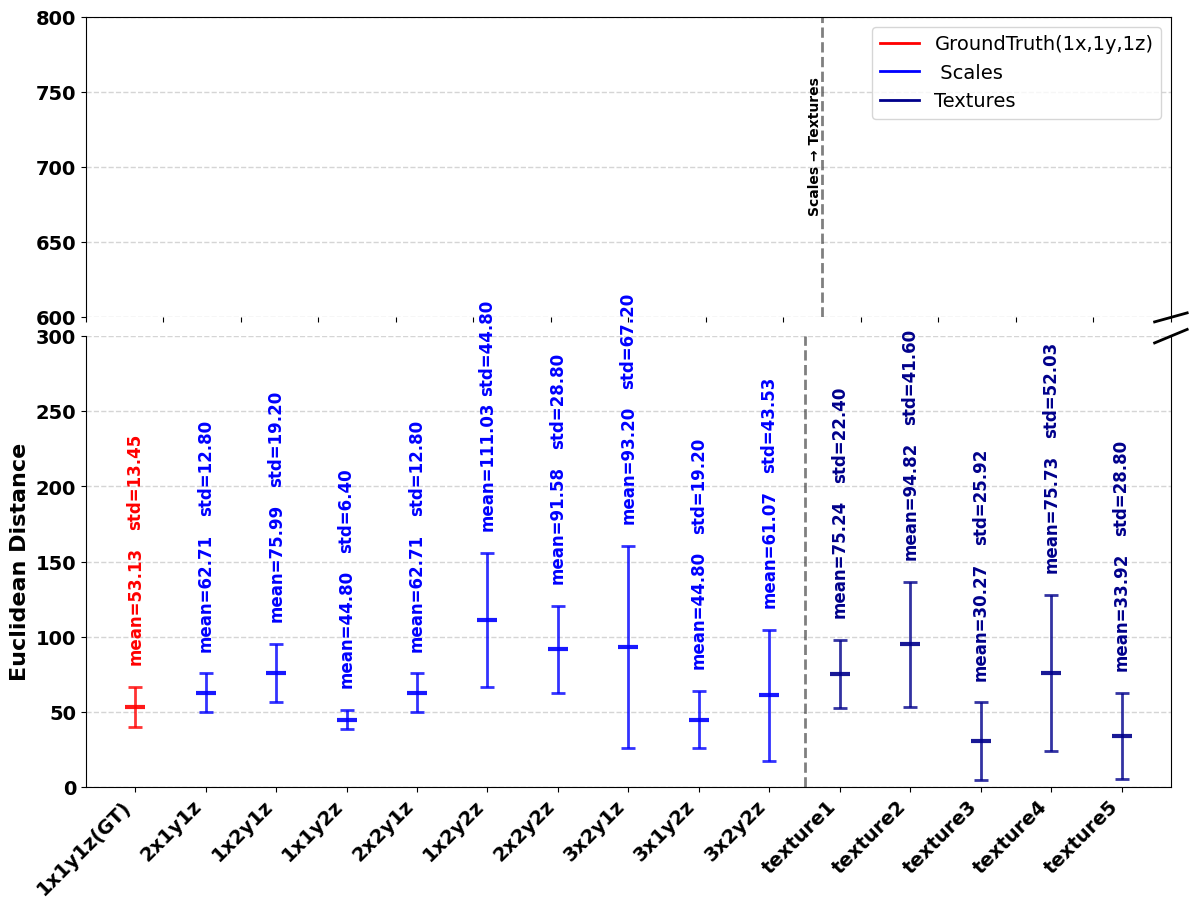


DATA SUMMARY
   Type       Name  Mean Euclidean Distance  Std Euclidean Distance
  Scale 1x1y1z(GT)                   0.8301                  0.2101
  Scale     2x1y1z                   0.9798                  0.2000
  Scale     1x2y1z                   1.1874                  0.3000
  Scale     1x1y2z                   0.7000                  0.1000
  Scale     2x2y1z                   0.9798                  0.2000
  Scale     1x2y2z                   1.7349                  0.7000
  Scale     2x2y2z                   1.4309                  0.4500
  Scale     3x2y1z                   1.4563                  1.0500
  Scale     3x1y2z                   0.7000                  0.3000
  Scale     3x2y2z                   0.9542                  0.6802
Texture   texture1                   1.1757                  0.3500
Texture   texture2                   1.4815                  0.6500
Texture   texture3                   0.4730                  0.4050
Texture   texture4                

In [32]:
"""
Inter-Rater Error Bar Chart with Broken Y-Axis
Creates error bar chart with broken y-axis (crops 300-650 range)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale'
DISTANCE_MULTIPLIER = 64  # Multiply Y-axis by 64

# Data from the results
data = {
    'Type': ['Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale',
             'Texture', 'Texture', 'Texture', 'Texture', 'Texture'],
    'Name': ['1x1y1z(GT)', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z', '3x2y1z', '3x1y2z', '3x2y2z',
             'texture1', 'texture2', 'texture3', 'texture4', 'texture5'],
    
    'Mean Euclidean Distance': [0.8301, 0.9798, 1.1874, 0.7000, 0.9798, 1.7349, 1.4309, 1.4563, 0.7000, 0.9542, 1.1757, 1.4815, 0.4730, 1.1833, 0.5300],
    'Std Euclidean Distance': [0.2101, 0.2000, 0.3000, 0.1000, 0.2000, 0.7000, 0.4500, 1.0500, 0.3000, 0.6802, 0.3500, 0.6500, 0.4050, 0.8130, 0.4500]
}

df = pd.DataFrame(data)

# Separate scales and textures
scale_data = df[df['Type'] == 'Scale']
texture_data = df[df['Type'] == 'Texture']

# Create figure with broken y-axis (crop 300-600)
# Note: High values (600-800) at top, low values (0-300) at bottom
# Top part is 2/3 of bottom part height, same scale step
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.05)  # Top is 2/3 of bottom

# Top subplot (600 to 800) - displayed at top (high values)
ax2 = fig.add_subplot(gs[0, 0])
# Bottom subplot (0 to 300) - displayed at bottom (low values)
ax1 = fig.add_subplot(gs[1, 0])

# Y-axis break parameters
Y_BOTTOM_MAX = 300
Y_TOP_MIN = 600
Y_TOP_MAX = 800

# Calculate x positions
x_pos_scale = np.arange(len(scale_data))
x_pos_texture = np.arange(len(scale_data), len(scale_data) + len(texture_data))

# Plot scales on both axes
scale_text_positions_bottom = []
scale_text_positions_top = []
if len(scale_data) > 0:
    scale_names = scale_data['Name'].tolist()
    scale_means = (scale_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_stds = (scale_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_colors = ['red' if name == '1x1y1z(GT)' else 'blue' for name in scale_names]
    
    for i, (mean, std, color, name) in enumerate(zip(scale_means, scale_stds, scale_colors, scale_names)):
        # Plot on bottom if value <= 300
        if mean <= Y_BOTTOM_MAX:
            ax1.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax1.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_bottom.append((x_pos_scale[i], mean, std, color, mean))
        # Plot on top if value >= 600
        elif mean >= Y_TOP_MIN:
            ax2.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax2.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_top.append((x_pos_scale[i], mean, std, color, mean))

# Plot textures on both axes
texture_text_positions_bottom = []
texture_text_positions_top = []
if len(texture_data) > 0:
    texture_names = texture_data['Name'].tolist()
    texture_means = (texture_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    texture_stds = (texture_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    texture_colors = ['darkblue'] * len(texture_names)
    
    for i, (mean, std, color, name) in enumerate(zip(texture_means, texture_stds, texture_colors, texture_names)):
        # Plot on bottom if value <= 300
        if mean <= Y_BOTTOM_MAX:
            ax1.errorbar(x_pos_texture[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax1.plot(x_pos_texture[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            texture_text_positions_bottom.append((x_pos_texture[i], mean, std, color, mean))
        # Plot on top if value >= 600
        elif mean >= Y_TOP_MIN:
            ax2.errorbar(x_pos_texture[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax2.plot(x_pos_texture[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            texture_text_positions_top.append((x_pos_texture[i], mean, std, color, mean))

# Combine all labels
all_names = scale_data['Name'].tolist() + texture_data['Name'].tolist()
all_x_pos = list(x_pos_scale) + list(x_pos_texture)

# Configure top subplot (600-800) - displayed at top (high values)
ax2.set_xticks(all_x_pos)
ax2.set_xticklabels([])  # Hide x labels on top subplot
ax2.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax2.set_ylim(bottom=Y_TOP_MIN, top=Y_TOP_MAX)
ax2.spines['bottom'].set_visible(False)  # Hide bottom spine (broken axis)

# Set same scale step for both subplots (50 units per step)
tick_step = 50
ax2.set_yticks(np.arange(Y_TOP_MIN, Y_TOP_MAX + tick_step, tick_step))

# Configure bottom subplot (0-300) - displayed at bottom (low values)
ax1.set_ylabel(f'Euclidean Distance', fontsize=16, fontweight='bold')
ax1.set_xticks(all_x_pos)
ax1.set_xticklabels(all_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax1.set_ylim(bottom=0, top=Y_BOTTOM_MAX)
ax1.spines['top'].set_visible(False)  # Hide top spine (broken axis)

# Set same scale step for both subplots (50 units per step)
ax1.set_yticks(np.arange(0, Y_BOTTOM_MAX + tick_step, tick_step))

# Add broken axis indicators (diagonal lines)
d = 0.015  # Size of diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=2)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)  # Bottom-right diagonal (at bottom of top subplot)

kwargs.update(transform=ax1.transAxes)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)  # Top-right diagonal (at top of bottom subplot)

# Add mean and std text vertically on top of each bar for SCALES (bottom subplot - 0-300, low values)
for i, (x_pos, mean, std, color, _) in enumerate(scale_text_positions_bottom):
    offset = Y_BOTTOM_MAX * 0.05
    text_y_base = mean + std + offset
    text_spacing = Y_BOTTOM_MAX * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax1.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax1.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add mean and std text vertically on top of each bar for SCALES (top subplot - 600-800, high values)
for i, (x_pos, mean, std, color, _) in enumerate(scale_text_positions_top):
    offset = (Y_TOP_MAX - Y_TOP_MIN) * 0.05
    text_y_base = mean + std + offset
    text_spacing = (Y_TOP_MAX - Y_TOP_MIN) * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax2.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax2.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add mean and std text vertically on top of each bar for TEXTURES (bottom subplot - 0-300, low values)
for x_pos, mean, std, color, _ in texture_text_positions_bottom:
    offset = Y_BOTTOM_MAX * 0.05
    text_y_base = mean + std + offset
    text_spacing = Y_BOTTOM_MAX * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax1.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax1.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add mean and std text vertically on top of each bar for TEXTURES (top subplot - 600-800, high values)
for x_pos, mean, std, color, _ in texture_text_positions_top:
    offset = (Y_TOP_MAX - Y_TOP_MIN) * 0.05
    text_y_base = mean + std + offset
    text_spacing = (Y_TOP_MAX - Y_TOP_MIN) * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax2.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax2.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add vertical line to separate scales and textures (on both axes)
if len(scale_data) > 0 and len(texture_data) > 0:
    ax1.axvline(x=len(scale_data) - 0.5, color='black', linestyle='--', linewidth=2, alpha=0.5)
    ax2.axvline(x=len(scale_data) - 0.5, color='black', linestyle='--', linewidth=2, alpha=0.5)
    ax2.text(len(scale_data) - 0.5, Y_TOP_MAX * 0.95, 'Scales → Textures', 
           rotation=90, ha='right', va='top', fontsize=10, fontweight='bold')

# Add legend (on top subplot - ax2, high values)
legend_elements = [
    plt.Line2D([0], [0], color='red', linewidth=2, marker='_', markersize=15, label='GroundTruth(1x,1y,1z)'),
    plt.Line2D([0], [0], color='blue', linewidth=2, marker='_', markersize=15, label=' Scales'),
    plt.Line2D([0], [0], color='darkblue', linewidth=2, marker='_', markersize=15, label='Textures')
]
ax2.legend(handles=legend_elements, fontsize=14, loc='upper right')
plt.setp(ax1.get_yticklabels(), fontsize=14, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=14, fontweight='bold')

plt.tight_layout()

# Save plot
interrater_path = os.path.join(BASE_DIR, 'inter_rater_euclidean_distance_error_bar_broken_axis.png')
plt.savefig(interrater_path, dpi=300, bbox_inches='tight')
print(f"✓ Inter-rater error bar chart with broken axis saved to: {interrater_path}")
plt.show()

# Display data summary
print("\n" + "="*70)
print("DATA SUMMARY")
print("="*70)
print(df.to_string(index=False))
print("="*70)


✓ Inter-rater error bar chart saved to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\inter_rater_euclidean_distance_error_bar.png


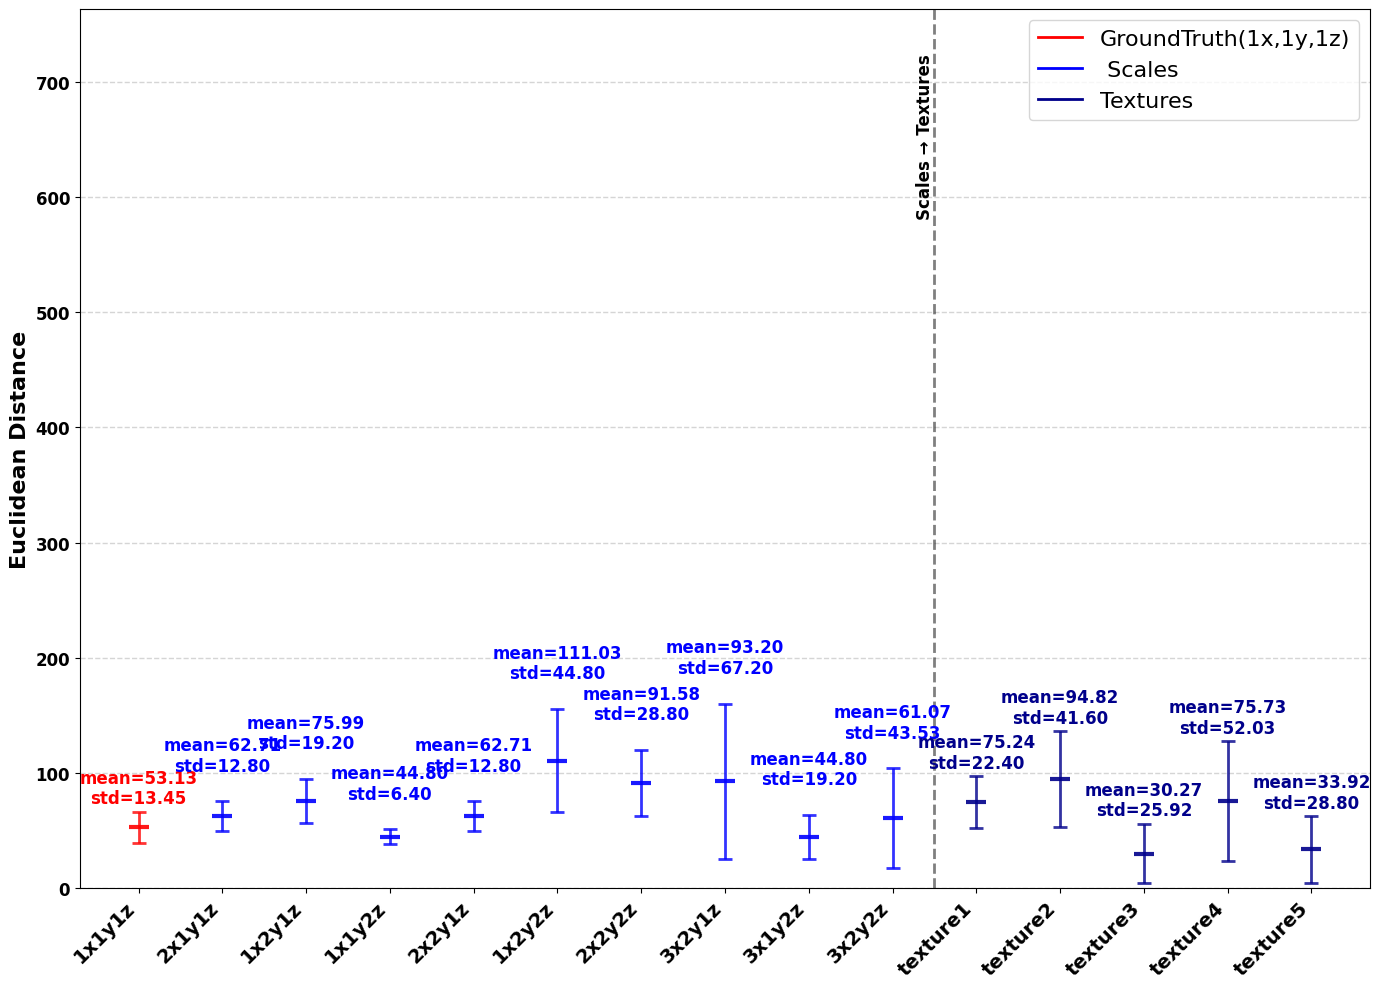


DATA SUMMARY
   Type     Name  Mean Euclidean Distance  Std Euclidean Distance
  Scale   1x1y1z                   0.8301                  0.2101
  Scale   2x1y1z                   0.9798                  0.2000
  Scale   1x2y1z                   1.1874                  0.3000
  Scale   1x1y2z                   0.7000                  0.1000
  Scale   2x2y1z                   0.9798                  0.2000
  Scale   1x2y2z                   1.7349                  0.7000
  Scale   2x2y2z                   1.4309                  0.4500
  Scale   3x2y1z                   1.4563                  1.0500
  Scale   3x1y2z                   0.7000                  0.3000
  Scale   3x2y2z                   0.9542                  0.6802
Texture texture1                   1.1757                  0.3500
Texture texture2                   1.4815                  0.6500
Texture texture3                   0.4730                  0.4050
Texture texture4                   1.1833                  0.8

In [13]:
"""
Inter-Rater Error Bar Chart
Creates error bar chart from Euclidean distance data (Scales and Textures)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale'
DISTANCE_MULTIPLIER = 64  # Multiply Y-axis by 0.5

# Data from the results
data = {
    'Type': ['Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale',
             'Texture', 'Texture', 'Texture', 'Texture', 'Texture'],
    'Name': ['1x1y1z', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z', '3x2y1z', '3x1y2z', '3x2y2z',
             'texture1', 'texture2', 'texture3', 'texture4', 'texture5'],
    
    'Mean Euclidean Distance': [0.8301, 0.9798, 1.1874, 0.7000, 0.9798, 1.7349, 1.4309, 1.4563, 0.7000, 0.9542, 1.1757, 1.4815, 0.4730, 1.1833, 0.5300],
    'Std Euclidean Distance': [0.2101, 0.2000, 0.3000, 0.1000, 0.2000, 0.7000, 0.4500, 1.0500, 0.3000, 0.6802, 0.3500, 0.6500, 0.4050, 0.8130, 0.4500]
}

df = pd.DataFrame(data)

# Separate scales and textures
scale_data = df[df['Type'] == 'Scale']
texture_data = df[df['Type'] == 'Texture']

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Calculate x positions
x_pos_scale = np.arange(len(scale_data))
x_pos_texture = np.arange(len(scale_data), len(scale_data) + len(texture_data))

# Plot scales
scale_text_positions = []  # Store positions for text labels
if len(scale_data) > 0:
    scale_names = scale_data['Name'].tolist()
    scale_means = (scale_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_stds = (scale_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_colors = ['red' if name == '1x1y1z' else 'blue' for name in scale_names]
    
    for i, (mean, std, color, name) in enumerate(zip(scale_means, scale_stds, scale_colors, scale_names)):
        ax.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
        ax.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
        # Store position for text (will be added after ylim is set)
        scale_text_positions.append((x_pos_scale[i], mean, std, color, mean))

# Plot textures
texture_text_positions = []  # Store positions for text labels
if len(texture_data) > 0:
    texture_names = texture_data['Name'].tolist()
    texture_means = (texture_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    texture_stds = (texture_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    texture_colors = ['darkblue'] * len(texture_names)
    
    for i, (mean, std, color, name) in enumerate(zip(texture_means, texture_stds, texture_colors, texture_names)):
        ax.errorbar(x_pos_texture[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
        ax.plot(x_pos_texture[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
        # Store position for text (will be added after ylim is set)
        texture_text_positions.append((x_pos_texture[i], mean, std, color, mean))

# Combine all labels
all_names = scale_data['Name'].tolist() + texture_data['Name'].tolist()
all_x_pos = list(x_pos_scale) + list(x_pos_texture)

# Set labels and title
# ax.set_xlabel('Scale / Texture', fontsize=24, fontweight='bold')             
ax.set_ylabel(f'Euclidean Distance', fontsize=16, fontweight='bold')
# ax.set_title('Inter-Rater Agreement Analysis: Scale and Texture-Based Euclidean Distance\n(Red=Original, Blue= Scales | Textures: Dark Blue)', 
#              fontsize=24, fontweight='bold', pad=10)
ax.set_xticks(all_x_pos)
ax.set_xticklabels(all_names, rotation=45, ha='right', fontsize=14,fontweight='bold')
ax.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax.set_ylim(bottom=0, top=763)

# Configurable offsets (adjust these values as needed)
OFFSET_FIRST = 0.005   # Offset for first item
OFFSET_SCALES = 0.03  # Offset for scales (except first)
OFFSET_TEXTURES = 0.005  # Offset for textures

y_max = ax.get_ylim()[1]

# Add mean and std text on top of each bar for SCALES
for i, (x_pos, mean, std, color, _) in enumerate(scale_text_positions):
    if i == 0:  # First item
        offset = y_max * OFFSET_FIRST
    else:  # Other scales
        offset = y_max * OFFSET_SCALES
    text_y = mean + std + offset
    ax.text(x_pos, text_y, f'mean={mean:.2f}\nstd={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color)

# Add mean and std text on top of each bar for TEXTURES
for x_pos, mean, std, color, _ in texture_text_positions:
    offset = y_max * OFFSET_TEXTURES
    text_y = mean + std + offset
    ax.text(x_pos, text_y, f'mean={mean:.2f}\nstd={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color)

# Add vertical line to separate scales and textures
if len(scale_data) > 0 and len(texture_data) > 0:
    ax.axvline(x=len(scale_data) - 0.5, color='black', linestyle='--', linewidth=2, alpha=0.5)
    ax.text(len(scale_data) - 0.5, ax.get_ylim()[1] * 0.95, 'Scales → Textures', 
           rotation=90, ha='right', va='top', fontsize=12, fontweight='bold')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], color='red', linewidth=2, marker='_', markersize=15, label='GroundTruth(1x,1y,1z)'),
    plt.Line2D([0], [0], color='blue', linewidth=2, marker='_', markersize=15, label=' Scales'),
    plt.Line2D([0], [0], color='darkblue', linewidth=2, marker='_', markersize=15, label='Textures')
]
ax.legend(handles=legend_elements, fontsize=16, loc='upper right')
plt.setp(ax.get_yticklabels(), fontsize=12, fontweight='bold')

plt.tight_layout()

# Save plot
interrater_path = os.path.join(BASE_DIR, 'inter_rater_euclidean_distance_error_bar.png')
plt.savefig(interrater_path, dpi=300, bbox_inches='tight')
print(f"✓ Inter-rater error bar chart saved to: {interrater_path}")
plt.show()

# Display data summary
print("\n" + "="*70)
print("DATA SUMMARY")
print("="*70)
print(df.to_string(index=False))
print("="*70)


#synthetic texture euclidean distance 

result of google colab 

#error rate plot

In [9]:
"""
Complete Scale Experiment Script
Creates ground truth, trains model, extracts coordinates,calculate Euclidean distance and error rate
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data, Batch
import os
import time
import pandas as pd
from tqdm import tqdm
import pickle
import random

# ============================================================================
# Configuration
# ============================================================================
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale'
os.makedirs(BASE_DIR, exist_ok=True)

# Original dimensions
ORIGINAL_X = 681
ORIGINAL_Y = 344
ORIGINAL_Z = 12

# For now, only original scale
SCALES = [
    ('original', 1, 1, 1),
    ('2x1y1z', 2, 1, 1),
    ('1x2y1z', 1, 2, 1),
    ('1x1y2z', 1, 1, 2),
    ('2x2y1z', 2, 2, 1),
    ('1x2y2z', 1, 2, 2),
    ('2x2y2z', 2, 2, 2),
    ('3x2y1z', 3, 2, 1),
    ('3x1y2z', 3, 1, 2),
    ('3x2y2z', 3, 2, 2)
]

TOP_K = 100
Z_FIXED = 5
MAX_RADIUS = 10            # Used for graphs, GT scoring
STEP_SIZE = 5

# Euclidean distance thresholds for accuracy calculation
EUCLIDEAN_THRESHOLDS = [2, 4, 8]  # Multiple thresholds to evaluate


# ============================================================================
# Helper Functions
# ============================================================================
def calculate_distance(x1, y1, z1, x2, y2, z2):
    """Calculate 3D Euclidean distance between two points"""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)


# ============================================================================
# 1. Create Ground Truth with Different Scales
# ============================================================================
def create_groundtruth(scale_name, x_scale, y_scale, z_scale, output_dir):
    """Create ground truth data with specified scale"""
    print(f"\n{'='*70}")
    print(f"Creating Ground Truth: {scale_name} (X={x_scale}x, Y={y_scale}x, Z={z_scale}x)")
    print(f"{'='*70}")

    num_channels = 4
    value_range = (0, 10)

    # Calculate scaled dimensions
    x_dim = ORIGINAL_X * x_scale
    y_dim = ORIGINAL_Y * y_scale
    z_dim = ORIGINAL_Z * z_scale
    num_values = value_range[1] - value_range[0] + 1

    print(f"  Dimensions: X={x_dim}, Y={y_dim}, Z={z_dim}")

    # Create 5D array: (C, V, Z, Y, X)
    data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)

    # Parameters for random colonies (scaled by 4x)
    max_radius = 200  # 50*4
    num_colonies_per_line = 8  # Number of colony centers per line

    # Channel 0: 3D Arc from (0,0,0) to (x_max, y_max, z_max) - create once for all z
    num_arc_points = num_colonies_per_line * 3
    t_values = np.linspace(0, 1, num_arc_points)
    arc_amplitude = 0.3  # How much the arc curves (as fraction of dimensions)

    for t in t_values:
        # Base linear interpolation from (0,0,0) to (x_max, y_max, z_max)
        x_arc_base = t * (x_dim - 1)
        y_arc_base = t * (y_dim - 1)
        z_arc_base = t * (z_dim - 1)
        
        # Add arc curvature: sinusoidal elevation in y and z
        angle = t * np.pi  # From 0 to π
        arc_elevation_y = arc_amplitude * (y_dim - 1) * np.sin(angle)
        arc_elevation_z = arc_amplitude * (z_dim - 1) * np.sin(angle)
        
        # Final arc position
        x_arc = x_arc_base
        y_arc = y_arc_base + arc_elevation_y
        z_arc = z_arc_base + arc_elevation_z
        
        # Ensure within bounds
        x_arc = int(np.clip(x_arc, 0, x_dim - 1))
        y_arc = int(np.clip(y_arc, 0, y_dim - 1))
        z_arc = int(np.clip(z_arc, 0, z_dim - 1))
        
        # Create colony at this arc point in 3D space
        radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
        cloud_points = create_random_cloud(x_arc, y_arc, z_arc, radius, z_dim, y_dim, x_dim)
        
        # Set points for all positions in the cloud
        for x, y, z_val in cloud_points:
            if 0 <= x < x_dim and 0 <= y < y_dim and 0 <= z_val < z_dim:
                random_value = np.random.randint(6, 11)
                data[0, random_value, z_val, y, x] = 1

    # Generate data with random colony clouds (non-linear pattern from syntheticcreation.ipynb)
    for i in range(0, 3):
        for z in range(z_dim):
            # Channel 0: Second curved vertical line (concave) - only for i=1
            if i == 1:
                # Concave vertical curve (scaled by 4x: 152+80*1 = 232)
                x_base = int((152 + 80 * i) * x_scale / 1)  # 152+80*1 = 232
                y_center = y_dim / 2  # Center of the curve
                
                # Inverse convex (concave) curve: creates an elliptical curve bulging inward
                amplitude_curve = 480  # 120*4 (scaled by 4x)
                
                # Create colony centers along the curved line
                colony_y_positions = np.linspace(0, y_dim - 1, num_colonies_per_line * 2)
                
                for colony_y in colony_y_positions:
                    # Calculate x position on the curve
                    y_normalized = (colony_y - y_center) / (y_dim / 2)  # Normalize to [-1, 1]
                    y_normalized = np.clip(y_normalized, -1, 1)
                    
                    # Elliptical curve: 1 - y_normalized^2 creates a smooth oval shape
                    curve_offset = amplitude_curve * (1 - y_normalized**2)
                    
                    # Concave inward (inverse convex)
                    curve_x = x_base - curve_offset
                    
                    # Add small random offset perpendicular to curve
                    center_x = int(curve_x + np.random.uniform(-32, 32))  # -8*4 to 8*4
                    center_y = int(colony_y + np.random.uniform(-20, 20))  # -5*4 to 5*4
                    center_x = int(np.clip(center_x, 0, x_dim - 1))
                    center_y = int(np.clip(center_y, 0, y_dim - 1))
                    
                    radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
                    cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                    for x, y, z_val in cloud_points:
                        if z_val == z:  # Only set points in current z slice
                            random_value = np.random.randint(6, 11)
                            data[0, random_value, z, y, x] = 1
            
            # Channel 1: Semi-sinusoidal horizontal line - colonies on peaks
            # Sinusoidal pattern: y = y_base + amplitude * sin(frequency * x + phase)
            y_base = int((72 + 80 * i) * y_scale / 1)  # Scaled: 72+80*i (18*4+20*4*i)
            target_peak_y = 600  # Scaled: 150*4
            
            # Calculate amplitude so that peak reaches target_peak_y
            amplitude = max(200, min(target_peak_y - y_base, y_dim - y_base - 200))  # 50*4, scaled
            
            # Scale frequency inversely with x_dim (3 cycles across width)
            frequency = 2 * np.pi / (x_dim / 3)  # 3 cycles across width
            phase = i * np.pi / 2  # Different phase for each i
            
            # Find peaks of sinusoidal function
            x_samples = []
            k_range = int(x_dim * frequency / (2 * np.pi)) + 1
            for k in range(-1, k_range + 1):
                peak_x = (np.pi / 2 + 2 * np.pi * k - phase) / frequency
                if 0 <= peak_x < x_dim:
                    x_samples.append(peak_x)
            
            # Limit number of colonies
            if len(x_samples) > num_colonies_per_line * 4:
                indices = np.linspace(0, len(x_samples) - 1, num_colonies_per_line * 2, dtype=int)
                x_samples = [x_samples[idx] for idx in indices]
            
            # Create colonies at peak positions
            for x_sample in x_samples:
                peak_y = y_base + amplitude
                
                # Add small random offset (scaled by 4x)
                center_x = int(x_sample + np.random.uniform(-32, 32))  # -8*4 to 8*4
                center_y = int(peak_y + np.random.uniform(-20, 20))  # -5*4 to 5*4
                center_x = int(np.clip(center_x, 0, x_dim - 1))
                center_y = int(np.clip(center_y, 0, y_dim - 1))
                
                radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
                cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                for x, y, z_val in cloud_points:
                    if z_val == z:
                        random_value = np.random.randint(6, 11)
                        data[1, random_value, z, y, x] = 1
            
            # Channel 2: Semi-sinusoidal diagonal line (y = x + c + sin) - colonies on peaks
            c_values = [-240 * max(x_scale, y_scale), 0]  # Scaled: -240 (60*4)
            for c in c_values:
                # Sinusoidal diagonal: y = x + c + amplitude * sin(frequency * x + phase)
                target_peak_y = 600  # Scaled: 150*4
                diagonal_base = c
                amplitude_sin = max(120, min(400, (target_peak_y - diagonal_base) / 2))  # Scaled: 30*4, 100*4
                frequency_sin = 2 * np.pi / (x_dim / 4)  # 4 cycles
                phase_sin = i * np.pi / 3
                
                # Find peaks along diagonal
                x_range_valid = range(max(0, -c), min(x_dim, y_dim - c))
                if len(x_range_valid) == 0:
                    continue
                
                # Sample points along diagonal and find peaks
                x_samples_diag = np.linspace(x_range_valid.start, x_range_valid.stop - 1, 
                                             num_colonies_per_line * 8)
                peak_positions = []
                for idx in range(1, len(x_samples_diag) - 1):
                    x_prev = x_samples_diag[idx - 1]
                    x_curr = x_samples_diag[idx]
                    x_next = x_samples_diag[idx + 1]
                    
                    y_prev = x_prev + c + amplitude_sin * np.sin(frequency_sin * x_prev + phase_sin)
                    y_curr = x_curr + c + amplitude_sin * np.sin(frequency_sin * x_curr + phase_sin)
                    y_next = x_next + c + amplitude_sin * np.sin(frequency_sin * x_next + phase_sin)
                    
                    # Check if this is a peak (local maximum)
                    if y_curr > y_prev and y_curr > y_next and 0 <= y_curr < y_dim:
                        peak_positions.append((x_curr, y_curr))
                
                # Select evenly spaced peaks
                if len(peak_positions) > num_colonies_per_line * 2:
                    indices = np.linspace(0, len(peak_positions) - 1, num_colonies_per_line * 2, dtype=int)
                    peak_positions = [peak_positions[idx] for idx in indices]
                
                # Create colonies at peak positions
                for x_peak, y_peak in peak_positions:
                    # Add random offset perpendicular to curve (scaled by 4x)
                    perp_offset = np.random.uniform(-48, 48)  # -12*4 to 12*4
                    center_x = int(x_peak + perp_offset / np.sqrt(2))
                    center_y = int(y_peak - perp_offset / np.sqrt(2))
                    center_x = int(np.clip(center_x, 0, x_dim - 1))
                    center_y = int(np.clip(center_y, 0, y_dim - 1))
                    
                    radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
                    cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                    for x, y, z_val in cloud_points:
                        if z_val == z:
                            random_value = np.random.randint(6, 11)
                            data[2, random_value, z, y, x] = 1
            
            # Channel 3: Diagonal lines with slope -1 (y = -x + d) - convert to random colonies
            d_values = [240 * max(x_scale, y_scale), 480 * max(x_scale, y_scale)]  # Scaled: 240 (60*4), 480 (120*4)
            for d in d_values:
                # Create colony centers along diagonal line
                x_samples = np.linspace(max(0, d - y_dim + 1), min(x_dim - 1, d), num_colonies_per_line)
                for x_sample in x_samples:
                    if x_sample < 0 or x_sample >= x_dim:
                        continue
                    y_line = -x_sample + d
                    if y_line < 0 or y_line >= y_dim:
                        continue
                    
                    # Add random offset perpendicular to line (scaled by 4x)
                    perp_offset = np.random.uniform(-60, 60)  # -15*4 to 15*4
                    center_x = int(x_sample + perp_offset / np.sqrt(2))
                    center_y = int(y_line + perp_offset / np.sqrt(2))
                    center_x = int(np.clip(center_x, 0, x_dim - 1))
                    center_y = int(np.clip(center_y, 0, y_dim - 1))
                    
                    radius = np.random.uniform(40, max_radius)  # 10*4 to 50*4
                    cloud_points = create_random_cloud(center_x, center_y, z, radius, z_dim, y_dim, x_dim)
                    for x, y, z_val in cloud_points:
                        if z_val == z:
                            random_value = np.random.randint(6, 11)
                            data[3, random_value, z, y, x] = 1

    # Save ground truth
    filename = f'groundtruth_{scale_name}.npy'
    filepath = os.path.join(output_dir, filename)
    np.save(filepath, data)
    print(f"✓ Saved ground truth to: {filepath}")
    print(f"  Shape: {data.shape}, Size: {data.nbytes / 1024 / 1024:.2f} MB")

    return data, filepath


# ============================================================================
# 2. Create Subgraphs from Ground Truth
# ============================================================================
def create_subgraphs(data, scale_name, output_dir):
    """Create subgraphs from ground truth data"""
    print(f"\n{'='*70}")
    print(f"Creating Subgraphs: {scale_name}")
    print(f"{'='*70}")

    num_channels, num_values, z_dim, y_dim, x_dim = data.shape
    z_idx = Z_FIXED if Z_FIXED < z_dim else z_dim // 2

    print(f"  Using z={z_idx}, Dimensions: {y_dim}x{x_dim}")

    # Pre-compute intensity matrix and mask per channel
    print("  Pre-computing intensity matrix...")
    intensity_matrix = np.zeros((y_dim, x_dim, num_channels), dtype=np.float32)
    channel_mask = np.zeros((y_dim, x_dim, num_channels), dtype=bool)

    for channel in range(num_channels):
        # channel_data: (V, Y, X) at fixed z
        channel_data = data[channel, :, z_idx, :, :]
        value_indices = np.argmax(channel_data, axis=0)
        mask = channel_data.sum(axis=0) > 0
        intensity_matrix[:, :, channel] = np.where(mask, value_indices.astype(np.float32), 0.0)
        channel_mask[:, :, channel] = mask

    channel_counts = channel_mask.sum(axis=2)

    # Generate graph centers
    graph_centers = []
    for x in range(0, x_dim, STEP_SIZE):
        for y in range(0, y_dim, STEP_SIZE):
            graph_centers.append((x, y, z_idx))

    print(f"  Total graph centers: {len(graph_centers)}")

    # Create subgraphs
    all_subgraphs = []
    print("  Creating subgraphs...")

    for center_idx, (center_x, center_y, center_z) in enumerate(tqdm(graph_centers, desc="Processing")):
        x_min = max(0, int(center_x - MAX_RADIUS))
        x_max = min(x_dim, int(center_x + MAX_RADIUS) + 1)
        y_min = max(0, int(center_y - MAX_RADIUS))
        y_max = min(y_dim, int(center_y + MAX_RADIUS) + 1)

        nodes = []
        node_positions = []
        node_active_channels = []

        for y in range(y_min, y_max):
            for x in range(x_min, x_max):
                if channel_counts[y, x] > 0:
                    distance = calculate_distance(center_x, center_y, center_z, x, y, z_idx)
                    if distance <= MAX_RADIUS:
                        active_channels = np.where(channel_mask[y, x, :])[0].tolist()
                        intensities = intensity_matrix[y, x, active_channels]
                        nodes.append(intensities)
                        node_positions.append((x, y, z_idx))
                        node_active_channels.append(active_channels)

        if len(nodes) == 0:
            continue

        max_channels = max(len(channels) for channels in node_active_channels)
        padded_nodes = []
        for i, intensities in enumerate(nodes):
            active_ch = node_active_channels[i]
            num_ch = len(active_ch)
            if num_ch < max_channels:
                padded = np.zeros(max_channels, dtype=np.float32)
                padded[:num_ch] = intensities
                padded_nodes.append(padded)
            else:
                padded_nodes.append(intensities)

        node_features = np.array(padded_nodes, dtype=np.float32)
        node_positions_array = np.array(node_positions, dtype=np.int32)
        num_nodes = len(node_features)

        if num_nodes < 2:
            continue

        # Create edges
        node_positions_np = node_positions_array.astype(np.float32)
        if num_nodes < 5000:
            diff = node_positions_np[:, np.newaxis, :] - node_positions_np[np.newaxis, :, :]
            distances_matrix = np.sqrt(np.sum(diff**2, axis=2))
            edge_mask = (distances_matrix <= MAX_RADIUS) & (distances_matrix > 0)
            edge_i, edge_j = np.where(edge_mask)
        else:
            # For large graphs, use iterative approach
            edge_i, edge_j = [], []
            for i in range(num_nodes):
                for j in range(i+1, num_nodes):
                    dist = calculate_distance(
                        node_positions_array[i,0], node_positions_array[i,1], node_positions_array[i,2],
                        node_positions_array[j,0], node_positions_array[j,1], node_positions_array[j,2]
                    )
                    if 0 < dist <= MAX_RADIUS:
                        edge_i.extend([i, j])
                        edge_j.extend([j, i])
            edge_i, edge_j = np.array(edge_i), np.array(edge_j)

        if len(edge_i) == 0:
            continue

        edge_index = torch.tensor([edge_i, edge_j], dtype=torch.long)
        edge_weights_np = np.array([
            calculate_distance(
                node_positions_array[edge_i[k],0], node_positions_array[edge_i[k],1], node_positions_array[edge_i[k],2],
                node_positions_array[edge_j[k],0], node_positions_array[edge_j[k],1], node_positions_array[edge_j[k],2]
            ) for k in range(len(edge_i))
        ], dtype=np.float32)

        node_values = node_features.sum(axis=1)

        edge_attr = torch.tensor(edge_weights_np, dtype=torch.float32)
        x_tensor = torch.tensor(node_features, dtype=torch.float32)
        node_values_tensor = torch.tensor(node_values, dtype=torch.float32)

        graph = Data(
            x=x_tensor,
            edge_index=edge_index,
            edge_attr=edge_attr,
            center=(center_x, center_y, center_z),
            center_idx=center_idx,
            node_positions=[tuple(pos) for pos in node_positions_array],
            node_values=node_values_tensor,
            max_channels=max_channels
        )

        all_subgraphs.append(graph)

    # Save subgraphs
    filename = f'Subgraph_{scale_name}.pt'
    filepath = os.path.join(output_dir, filename)
    torch.save(all_subgraphs, filepath)
    print(f"✓ Saved {len(all_subgraphs)} subgraphs to: {filepath}")
    print(f"  File size: {os.path.getsize(filepath) / 1024 / 1024:.2f} MB")

    return all_subgraphs, filepath


# ============================================================================
# 3. Model Classes and Functions
# ============================================================================

def prepare_graph_for_batching(graph, target_channels=4):
    """Prepare graph for batching by padding to target_channels"""
    x = graph.x.clone()
    current_channels = x.shape[1]
    if current_channels < target_channels:
        padding = torch.zeros(x.shape[0], target_channels - current_channels, dtype=x.dtype, device=x.device)
        x = torch.cat([x, padding], dim=1)
    elif current_channels > target_channels:
        x = x[:, :target_channels]

    clean_graph = Data(x=x, edge_index=graph.edge_index.clone())
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        clean_graph.edge_attr = graph.edge_attr.clone()
    if hasattr(graph, 'center'):
        clean_graph._original_center = graph.center

    return clean_graph


def graph_augment(graph, node_mask_ratio=0.1, edge_drop_ratio=0.05, target_channels=4):
    """Augment graph for contrastive learning"""
    aug_graph = prepare_graph_for_batching(graph, target_channels=target_channels)

    # Keep gt_score on augmented graph if present
    if hasattr(graph, 'gt_score'):
        aug_graph.gt_score = graph.gt_score

    num_nodes = aug_graph.x.shape[0]
    num_mask = int(num_nodes * node_mask_ratio)
    if num_mask > 0:
        mask_indices = torch.randperm(num_nodes)[:num_mask]
        aug_graph.x[mask_indices] = 0.0

    if edge_drop_ratio > 0 and aug_graph.edge_index.shape[1] > 0:
        num_edges = aug_graph.edge_index.shape[1]
        num_drop = int(num_edges * edge_drop_ratio)
        if num_drop > 0:
            keep_indices = torch.randperm(num_edges)[:(num_edges - num_drop)]
            aug_graph.edge_index = aug_graph.edge_index[:, keep_indices]
            if hasattr(aug_graph, 'edge_attr') and aug_graph.edge_attr is not None:
                aug_graph.edge_attr = aug_graph.edge_attr[keep_indices]

    return aug_graph


class ContrastiveGAT(nn.Module):
    """Graph Attention Network with Self-Supervised Contrastive Learning"""
    def __init__(self, in_channels=4, hidden_channels=64, projection_dim=32, num_heads=4, dropout=0.1, edge_dim=None):
        super(ContrastiveGAT, self).__init__()
        self.edge_dim = edge_dim
        gat_kwargs = dict(dropout=dropout)
        if self.edge_dim is not None and self.edge_dim > 0:
            gat_kwargs["edge_dim"] = self.edge_dim

        self.gat1 = GATConv(in_channels=in_channels, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat2 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=num_heads, concat=True, **gat_kwargs)
        self.gat3 = GATConv(in_channels=hidden_channels * num_heads, out_channels=hidden_channels, heads=1, concat=False, **gat_kwargs)

        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(hidden_channels * num_heads)
        self.norm2 = nn.LayerNorm(hidden_channels * num_heads)
        self.pool_dim = hidden_channels * 3

        self.projection = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, projection_dim)
        )

        self.interaction_head = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )

    def encode(self, x, edge_index, edge_attr=None, batch=None):
        if self.edge_dim is not None and self.edge_dim > 0 and edge_attr is not None:
            ea = edge_attr
        else:
            ea = None

        x = self.gat1(x, edge_index, ea)
        x = self.norm1(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.gat2(x, edge_index, ea)
        x = self.norm2(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.gat3(x, edge_index, ea)
        x = F.elu(x)

        return x

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        node_emb = self.encode(x, edge_index, edge_attr, batch)

        if batch is None:
            batch = torch.zeros(node_emb.shape[0], dtype=torch.long, device=node_emb.device)

        mean_pool = global_mean_pool(node_emb, batch)
        max_pool = global_max_pool(node_emb, batch)
        sum_pool = global_add_pool(node_emb, batch)

        graph_emb = torch.cat([mean_pool, max_pool, sum_pool], dim=1)

        proj_emb = self.projection(graph_emb)
        proj_emb = F.normalize(proj_emb, dim=1)

        interaction_score = self.interaction_head(graph_emb)

        return proj_emb, interaction_score


def contrastive_loss(z1, z2, temperature=0.1):
    """Contrastive loss (InfoNCE) for self-supervised learning"""
    batch_size = z1.shape[0]
    device = z1.device

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    sim_matrix = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(batch_size, device=device)

    loss = F.cross_entropy(sim_matrix, labels)
    loss_reverse = F.cross_entropy(sim_matrix.T, labels)

    return (loss + loss_reverse) / 2.0


def train_contrastive_model(model, graphs, device, epochs=10, batch_size=32, lr=0.01, gradient_accumulation_steps=4):
    """Train model with self-supervised contrastive learning"""
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    losses = []
    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4

    print(f"\n{'='*60}")
    print(f"Training Contrastive GAT Model")
    print(f"{'='*60}")
    print(f"  Epochs: {epochs}, Batch size: {batch_size}, LR: {lr}")
    print(f"  Total graphs: {len(graphs)}, Target channels: {target_channels}")

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    for epoch in range(epochs):
        epoch_losses = []
        optimizer.zero_grad()

        shuffled_graphs = graphs.copy()
        random.shuffle(shuffled_graphs)

        for batch_idx, i in enumerate(range(0, len(shuffled_graphs), batch_size)):
            batch_graphs = shuffled_graphs[i:i+batch_size]

            aug1_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]
            aug2_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]

            for g in aug1_graphs + aug2_graphs:
                g.x = g.x.to(device)
                g.edge_index = g.edge_index.to(device)
                if hasattr(g, 'edge_attr') and g.edge_attr is not None:
                    g.edge_attr = g.edge_attr.to(device)

            try:
                batch1 = Batch.from_data_list(aug1_graphs)
                batch2 = Batch.from_data_list(aug2_graphs)
            except Exception as e:
                print(f"Error creating batch: {e}")
                continue

            z1, pred1 = model(batch1.x, batch1.edge_index, getattr(batch1, "edge_attr", None), batch1.batch)
            z2, _ = model(batch2.x, batch2.edge_index, getattr(batch2, "edge_attr", None), batch2.batch)

            # Contrastive loss
            loss_contrast = contrastive_loss(z1, z2, temperature=0.1)

            # Supervised regression loss on gt_score (if available)
            loss_reg = torch.tensor(0.0, device=device)
            if hasattr(batch1, "gt_score"):
                try:
                    gt_scores = batch1.gt_score.to(device).float()
                    pred_scores = pred1.view(-1)
                    # Normalize scores for stability
                    if gt_scores.std() > 0:
                        gt_scores = (gt_scores - gt_scores.mean()) / (gt_scores.std() + 1e-8)
                    if pred_scores.std() > 0:
                        pred_scores = (pred_scores - pred_scores.mean()) / (pred_scores.std() + 1e-8)
                    loss_reg = F.mse_loss(pred_scores, gt_scores)
                except:
                    pass

            # Combined loss
            loss = (loss_contrast + 0.5 * loss_reg) / gradient_accumulation_steps
            loss.backward()

            del z1, z2, batch1, batch2, aug1_graphs, aug2_graphs
            if device.type == 'cuda':
                torch.cuda.empty_cache()

            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            epoch_losses.append(loss.item() * gradient_accumulation_steps)

        if len(epoch_losses) > 0 and (len(shuffled_graphs) // batch_size) % gradient_accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        avg_loss = np.mean(epoch_losses) if len(epoch_losses) > 0 else 0.0
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

    print(f"\n✓ Training complete!")
    return model, losses


# ============================================================================
# 4. Extract Coordinates using Model (predictions)
# ============================================================================
def find_max_interaction_positions(model, graphs, device, top_k=100):
    """
    Find positions with maximum interaction scores using the trained model.
    Uses the model's interaction_score, not any hand-crafted heuristic.
    """
    model.eval()
    all_scores = []

    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4

    with torch.no_grad():
        for graph in tqdm(graphs, desc="Processing graphs (model)"):
            # Prepare node features to have consistent channel dimension
            x = graph.x.clone()
            current_channels = x.shape[1]
            if current_channels < target_channels:
                padding = torch.zeros(x.shape[0], target_channels - current_channels, dtype=x.dtype, device=x.device)
                x = torch.cat([x, padding], dim=1)
            elif current_channels > target_channels:
                x = x[:, :target_channels]

            x = x.to(device)
            edge_index = graph.edge_index.to(device)
            if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
                edge_attr = graph.edge_attr.to(device)
            else:
                edge_attr = None

            # Forward pass: get model interaction score for this graph
            _, interaction_score = model(x, edge_index, edge_attr, batch=None)
            model_score = interaction_score.item()

            center = graph.center
            x_pos, y_pos, z_pos = center

            # Optional extra info for analysis
            num_nodes = graph.x.shape[0]
            num_edges = graph.edge_index.shape[1]
            num_channels = graph.x.shape[1] if hasattr(graph, 'x') else 0
            edge_density = num_edges / num_nodes if num_nodes > 0 else 0

            all_scores.append({
                'x': x_pos,
                'y': y_pos,
                'z': z_pos,
                'num_nodes': num_nodes,
                'num_edges': num_edges,
                'num_channels': num_channels,
                'edge_density': edge_density,
                'model_score': model_score
            })

    if len(all_scores) > 0:
        # Sort by model_score (descending): higher score = more important
        all_scores.sort(key=lambda x: x['model_score'], reverse=True)
        top_positions = all_scores[:top_k]
        return top_positions

    return []


# ============================================================================
# 5. Extract Ground-Truth Coordinates from Data (Option A)
# ============================================================================
def attach_gt_scores_to_graphs(data, graphs):
    """
    Compute a ground-truth score per graph center (same definition
    as extract_gt_coordinates_from_data) and store it as graph.gt_score.
    """
    num_channels, num_values, z_dim, y_dim, x_dim = data.shape

    # pattern_mask[z, y, x] = True if any channel / value > 0 at that voxel
    pattern_mask = (data > 0)          # (C, V, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=1)  # (C, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=0)  # (Z, Y, X)

    radius_sq = MAX_RADIUS ** 2

    for g in graphs:
        cx, cy, cz = g.center
        cx, cy, cz = int(cx), int(cy), int(cz)
        cz = max(0, min(z_dim - 1, cz))

        x_min = max(0, cx - MAX_RADIUS)
        x_max = min(x_dim, cx + MAX_RADIUS + 1)
        y_min = max(0, cy - MAX_RADIUS)
        y_max = min(y_dim, cy + MAX_RADIUS + 1)

        score = 0
        for y in range(y_min, y_max):
            dy2 = (y - cy) * (y - cy)
            for x in range(x_min, x_max):
                dx2 = (x - cx) * (x - cx)
                if dx2 + dy2 <= radius_sq:
                    if pattern_mask[cz, y, x]:
                        score += 1

        g.gt_score = float(score)

    return graphs


def extract_gt_coordinates_from_data(data, graphs, top_k=100):
    """
    Extract top coordinates from TRUE ground truth using Option A:
    A voxel is 'pattern' if ANY channel has a nonzero value.

    For each graph center, count how many pattern voxels are within radius MAX_RADIUS.
    Then pick the top_k centers with highest counts.
    """
    print("\nComputing ground-truth coordinates from data (Option A: ANY channel nonzero)...")

    num_channels, num_values, z_dim, y_dim, x_dim = data.shape

    # pattern_mask[z, y, x] = True if any channel / value > 0 at that voxel
    # data shape: (C, V, Z, Y, X)
    pattern_mask = (data > 0)        # bool (C, V, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=1)  # any over values -> (C, Z, Y, X)
    pattern_mask = pattern_mask.any(axis=0)  # any over channels -> (Z, Y, X)

    all_scores = []
    radius_sq = MAX_RADIUS ** 2

    for graph in tqdm(graphs, desc="Processing graphs (GT)"):
        cx, cy, cz = graph.center
        cx, cy, cz = int(cx), int(cy), int(cz)

        # Safety clamp
        cz = max(0, min(z_dim - 1, cz))

        x_min = max(0, cx - MAX_RADIUS)
        x_max = min(x_dim, cx + MAX_RADIUS + 1)
        y_min = max(0, cy - MAX_RADIUS)
        y_max = min(y_dim, cy + MAX_RADIUS + 1)

        score = 0
        for y in range(y_min, y_max):
            dy2 = (y - cy) * (y - cy)
            for x in range(x_min, x_max):
                dx2 = (x - cx) * (x - cx)
                if dx2 + dy2 <= radius_sq:
                    if pattern_mask[cz, y, x]:
                        score += 1

        all_scores.append({
            'x': cx,
            'y': cy,
            'z': cz,
            'score': score
        })

    if len(all_scores) > 0:
        # Sort by true pattern count (descending)
        all_scores.sort(key=lambda s: s['score'], reverse=True)
        top_positions = all_scores[:top_k]
        return top_positions

    return []


# ============================================================================
# 6. Compute Accuracy (+ radius-aware IoU "Accuracy" column)
# ============================================================================

def compute_accuracy(model_coords, gt_coords, tol=MAX_RADIUS):
    """
    Compute accuracy metrics based on Euclidean distance between model and ground truth coordinates.
    For each model point, finds the minimum Euclidean distance to any GT point.
    
    Metrics computed:
      - Euclidean distance statistics (mean, median, min, max, std)
      - Precision, Recall, F1 based on threshold matching
      - IoU (Accuracy) = matches / (model_points + gt_points - matches)
    """
    # Convert to simple lists of (x, y, z)
    model_points = [(int(c['x']), int(c['y']), int(c['z'])) for c in model_coords]
    gt_points    = [(int(c['x']), int(c['y']), int(c['z'])) for c in gt_coords]

    model_count = len(model_points)
    gt_count    = len(gt_points)

    if model_count == 0 or gt_count == 0:
        return {
            'matches': 0,
            'precision': 0.0,
            'recall': 0.0,
            'f1_score': 0.0,
            'model_count': model_count,
            'gt_count': gt_count,
            'accuracy_iou': 0.0,
            'mean_euclidean_distance': 0.0,
            'median_euclidean_distance': 0.0,
            'min_euclidean_distance': 0.0,
            'max_euclidean_distance': 0.0,
            'std_euclidean_distance': 0.0,
        }

    # Compute Euclidean distances: for each model point, find minimum distance to any GT point
    euclidean_distances = []
    for mx, my, mz in model_points:
        min_dist = float('inf')
        for gx, gy, gz in gt_points:
            dist = calculate_distance(mx, my, mz, gx, gy, gz)
            if dist < min_dist:
                min_dist = dist
        if min_dist != float('inf'):
            euclidean_distances.append(min_dist)
    
    # Euclidean distance statistics
    mean_euclidean = np.mean(euclidean_distances) if len(euclidean_distances) > 0 else 0.0
    median_euclidean = np.median(euclidean_distances) if len(euclidean_distances) > 0 else 0.0
    min_euclidean = np.min(euclidean_distances) if len(euclidean_distances) > 0 else 0.0
    max_euclidean = np.max(euclidean_distances) if len(euclidean_distances) > 0 else 0.0
    std_euclidean = np.std(euclidean_distances) if len(euclidean_distances) > 0 else 0.0

    # Method: For each model point, find the nearest GT point using Euclidean distance
    # A model point is considered "correct" if its distance to nearest GT <= threshold
    # Then calculate Precision, Recall, and F1 based on this matching
    
    # For each model point, find minimum Euclidean distance to any GT point
    correct_model_points = 0  # Model points within threshold
    matched_gt_indices = set()  # GT points that have been matched
    
    for mx, my, mz in model_points:
        # Find nearest GT point
        min_dist = float('inf')
        nearest_gt_idx = -1
        
        for gi, (gx, gy, gz) in enumerate(gt_points):
            dist = calculate_distance(mx, my, mz, gx, gy, gz)
            if dist < min_dist:
                min_dist = dist
                nearest_gt_idx = gi
        
        # If distance to nearest GT <= threshold, this model point is correct
        if min_dist <= tol:
            correct_model_points += 1
            if nearest_gt_idx >= 0:
                matched_gt_indices.add(nearest_gt_idx)
    
    matches = correct_model_points  # Number of correct model points
    matched_gt_count = len(matched_gt_indices)  # Number of unique GT points matched

    # Precision: Of all model points, how many are correct (within threshold)?
    precision = correct_model_points / model_count if model_count > 0 else 0.0
    
    # Recall: Of all GT points, how many were found by the model (matched)?
    recall = matched_gt_count / gt_count if gt_count > 0 else 0.0
    
    # F1 Score: Harmonic mean of Precision and Recall
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    union = model_count + gt_count - matches
    accuracy_iou = matches / union if union > 0 else 0.0

    return {
        'matches': matches,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'model_count': model_count,
        'gt_count': gt_count,
        'accuracy_iou': accuracy_iou,
        'mean_euclidean_distance': mean_euclidean,
        'median_euclidean_distance': median_euclidean,
        'min_euclidean_distance': min_euclidean,
        'max_euclidean_distance': max_euclidean,
        'std_euclidean_distance': std_euclidean,
    }


# ============================================================================
# 7. Main Execution Loop
# ============================================================================
if __name__ == "__main__":
    print("="*70)
    print("SCALE EXPERIMENT: Complete Pipeline (Euclidean Distance Based)")
    print("="*70)
    print("\nThis will:")
    print("  1. Create ground truth (synthetic)")
    print("  2. Generate subgraphs")
    print("  3. Train model")
    print("  4. Extract coordinates from model and GT")
    print("  5. Compute accuracy with Euclidean distance metrics")
    print("="*70)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nDevice: {device}\n")

    results = []

    for scale_name, x_scale, y_scale, z_scale in SCALES:
        print(f"\n{'#'*70}")
        print(f"Processing Scale: {scale_name} (X={x_scale}x, Y={y_scale}x, Z={z_scale}x)")
        print(f"{'#'*70}\n")

        # 1. Create ground truth data
        data, gt_filepath = create_groundtruth(scale_name, x_scale, y_scale, z_scale, BASE_DIR)

        # 2. Create subgraphs
        graphs, subgraphs_filepath = create_subgraphs(data, scale_name, BASE_DIR)

        # 3. Filter graphs
        min_nodes = 100
        filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
        print(f"\n  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes)")

        if len(filtered_graphs) == 0:
            print(f"  ⚠ No graphs after filtering! Skipping {scale_name}...")
            continue

        # 4. Attach GT scores to graphs for supervised training
        print(f"\n  Attaching GT scores to graphs...")
        filtered_graphs = attach_gt_scores_to_graphs(data, filtered_graphs)

        # 5. Train model
        print(f"\n  Training model for {scale_name}...")
        in_channels = max([g.x.shape[1] for g in filtered_graphs])
        edge_dim = 1 if any(hasattr(g, 'edge_attr') and g.edge_attr is not None for g in filtered_graphs) else None

        model = ContrastiveGAT(
            in_channels=in_channels,
            hidden_channels=32,
            projection_dim=16,
            num_heads=4,
            dropout=0.1,
            edge_dim=edge_dim
        ).to(device)

        subsampled_graphs = filtered_graphs[::2] if len(filtered_graphs) > 20000 else filtered_graphs
        model, losses = train_contrastive_model(
            model=model,
            graphs=subsampled_graphs,
            device=device,
            epochs=10,  # Increased from 1 to 20 for better learning
            batch_size=32,
            lr=0.1,  # Reduced from 0.01 to 0.001 for more stable training
            gradient_accumulation_steps=4
        )

        # Save model
        model_filepath = os.path.join(BASE_DIR, f'model_{scale_name}.pt')
        model_info = {
            'model_state_dict': model.state_dict(),
            'in_channels': in_channels,
            'hidden_channels': 32,
            'projection_dim': 16,
            'num_heads': 4,
            'dropout': 0.1,
            'edge_dim': edge_dim,
            'losses': losses
        }
        torch.save(model_info, model_filepath)
        print(f"  ✓ Saved model to: {model_filepath}")

        # 6. Run GAT model to extract top positions (reconstruct and find top positions)
        print(f"\n  Running GAT model to extract top positions...")
        model_coords = find_max_interaction_positions(model, filtered_graphs, device, top_k=TOP_K)

        # Save model_coords as pickle (for internal use)
        model_coords_filepath = os.path.join(BASE_DIR, f'model_coords_{scale_name}.pkl')
        with open(model_coords_filepath, 'wb') as f:
            pickle.dump(model_coords, f)
        print(f"  ✓ Saved model coordinates to: {model_coords_filepath}")

        # Save top_positions_result as pickle
        top_positions_pkl_filepath = os.path.join(BASE_DIR, f'top_positions_result_{scale_name}.pkl')
        with open(top_positions_pkl_filepath, 'wb') as f:
            pickle.dump(model_coords, f)
        print(f"  ✓ Saved top positions result (pkl) to: {top_positions_pkl_filepath}")

        # Save top_positions_result as numpy array (extract x, y, z coordinates)
        top_positions_array = np.array([[c['x'], c['y'], c['z']] for c in model_coords], dtype=np.int32)
        top_positions_npy_filepath = os.path.join(BASE_DIR, f'top_positions_result_{scale_name}.npy')
        np.save(top_positions_npy_filepath, top_positions_array)
        print(f"  ✓ Saved top positions result (npy) to: {top_positions_npy_filepath}")

        # 7. Extract ground-truth coordinates from data (Option A)
        # IMPORTANT: Use filtered_graphs (same as model training) for fair comparison
        print(f"\n  Extracting coordinates from ground truth (data, using filtered_graphs)...")
        gt_coords = extract_gt_coordinates_from_data(data, filtered_graphs, top_k=TOP_K)
        gt_coords_filepath = os.path.join(BASE_DIR, f'gt_coords{scale_name}.pkl')
        with open(gt_coords_filepath, 'wb') as f:
            pickle.dump(gt_coords, f)
        print(f"  ✓ Saved GT coordinates to: {gt_coords_filepath}")

        # 8. Compute accuracy for multiple thresholds
        print(f"\n  Computing accuracy for thresholds: {EUCLIDEAN_THRESHOLDS}...")
        
        for threshold in EUCLIDEAN_THRESHOLDS:
            accuracy = compute_accuracy(model_coords, gt_coords, tol=threshold)
            results.append({
                'Scale Name': scale_name,
                'Threshold': threshold,
                'F1 Score': f"{accuracy['f1_score']:.4f}",
                'Accuracy (IoU)': f"{accuracy['accuracy_iou']:.4f}",
            })
            print(
                f"  ✓ Threshold={threshold}: "
                f"F1={accuracy['f1_score']:.4f}, "
                f"Accuracy={accuracy['accuracy_iou']:.4f}"
            )

    # 8. Create final results table
    print(f"\n{'='*70}")
    print("FINAL RESULTS TABLE")
    print(f"{'='*70}\n")

    results_df = pd.DataFrame(results)
    
    # Create pivot tables for better visualization
    print("F1 Score by Scale and Threshold:")
    print("-" * 70)
    pivot_f1 = results_df.pivot(index='Scale Name', columns='Threshold', values='F1 Score')
    print(pivot_f1.to_string())
    print("\n")
    
    print("Accuracy (IoU) by Scale and Threshold:")
    print("-" * 70)
    pivot_accuracy = results_df.pivot(index='Scale Name', columns='Threshold', values='Accuracy (IoU)')
    print(pivot_accuracy.to_string())
    print("\n")
    
    # Save results table
    results_filepath = os.path.join(BASE_DIR, 'accuracy_results.csv')
    results_df.to_csv(results_filepath, index=False)
    
    # Save pivot tables
    pivot_f1.to_csv(os.path.join(BASE_DIR, 'f1_score_by_threshold.csv'))
    pivot_accuracy.to_csv(os.path.join(BASE_DIR, 'accuracy_by_threshold.csv'))
    
    print(f"✓ Results saved to: {results_filepath}")
    print(f"✓ Pivot tables saved to: {BASE_DIR}")

    print(f"\n{'='*70}")
    print("EXPERIMENT COMPLETE!")
    print(f"{'='*70}\n")


SCALE EXPERIMENT: Complete Pipeline (Euclidean Distance Based)

This will:
  1. Create ground truth (synthetic)
  2. Generate subgraphs
  3. Train model
  4. Extract coordinates from model and GT
  5. Compute accuracy with Euclidean distance metrics

Device: cpu


######################################################################
Processing Scale: original (X=1x, Y=1x, Z=1x)
######################################################################


Creating Ground Truth: original (X=1x, Y=1x, Z=1x)
  Dimensions: X=681, Y=344, Z=12
✓ Saved ground truth to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\groundtruth_original.npy
  Shape: (4, 11, 12, 344, 681), Size: 117.96 MB

Creating Subgraphs: original
  Using z=5, Dimensions: 344x681
  Pre-computing intensity matrix...
  Total graph centers: 9453
  Creating subgraphs...


Processing: 100%|██████████| 9453/9453 [00:00<00:00, 15577.85it/s]


✓ Saved 344 subgraphs to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\Subgraph_original.pt
  File size: 0.76 MB

  Filtered to 0 graphs (min 100 nodes)
  ⚠ No graphs after filtering! Skipping original...

######################################################################
Processing Scale: 2x1y1z (X=2x, Y=1x, Z=1x)
######################################################################


Creating Ground Truth: 2x1y1z (X=2x, Y=1x, Z=1x)
  Dimensions: X=1362, Y=344, Z=12
✓ Saved ground truth to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\groundtruth_2x1y1z.npy
  Shape: (4, 11, 12, 344, 1362), Size: 235.92 MB

Creating Subgraphs: 2x1y1z
  Using z=5, Dimensions: 344x1362
  Pre-computing intensity matrix...
  Total graph centers: 18837
  Creating subgraphs...


Processing: 100%|██████████| 18837/18837 [00:01<00:00, 16352.43it/s]


✓ Saved 382 subgraphs to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\Subgraph_2x1y1z.pt
  File size: 0.89 MB

  Filtered to 0 graphs (min 100 nodes)
  ⚠ No graphs after filtering! Skipping 2x1y1z...

######################################################################
Processing Scale: 1x2y1z (X=1x, Y=2x, Z=1x)
######################################################################


Creating Ground Truth: 1x2y1z (X=1x, Y=2x, Z=1x)
  Dimensions: X=681, Y=688, Z=12
✓ Saved ground truth to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\groundtruth_1x2y1z.npy
  Shape: (4, 11, 12, 688, 681), Size: 235.92 MB

Creating Subgraphs: 1x2y1z
  Using z=5, Dimensions: 688x681
  Pre-computing intensity matrix...
  Total graph centers: 18906
  Creating subgraphs...


...

Processing: 100%|██████████| 28221/28221 [00:01<00:00, 16113.35it/s]


✓ Saved 412 subgraphs to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\Subgraph_3x1y2z.pt
  File size: 0.92 MB

  Filtered to 0 graphs (min 100 nodes)
  ⚠ No graphs after filtering! Skipping 3x1y2z...

######################################################################
Processing Scale: 3x2y2z (X=3x, Y=2x, Z=2x)
######################################################################


Creating Ground Truth: 3x2y2z (X=3x, Y=2x, Z=2x)
  Dimensions: X=2043, Y=688, Z=24
✓ Saved ground truth to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\groundtruth_3x2y2z.npy
  Shape: (4, 11, 24, 688, 2043), Size: 1415.54 MB

Creating Subgraphs: 3x2y2z
  Using z=5, Dimensions: 688x2043
  Pre-computing intensity matrix...
  Total graph centers: 56442
  Creating subgraphs...


Processing: 100%|██████████| 56442/56442 [00:03<00:00, 17068.50it/s]


✓ Saved 328 subgraphs to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\Subgraph_3x2y2z.pt
  File size: 0.76 MB

  Filtered to 0 graphs (min 100 nodes)
  ⚠ No graphs after filtering! Skipping 3x2y2z...

FINAL RESULTS TABLE

F1 Score by Scale and Threshold:
----------------------------------------------------------------------


KeyError: 'Scale Name'

Google Colab result